
# Capítulo 4 — Modelagem passo a passo, sem “caixa-preta”

Este notebook foi preparado para continuar o TCC a partir do ponto em que o notebook `01_eda_ptbr.ipynb` parou.

## Objetivo

Construir, entender e avaliar uma cadeia experimental completa:

1. definir **o que estamos prevendo e em que momento a previsão acontece**;
2. evitar vazamento temporal (*data leakage*);
3. criar baselines históricos fortes;
4. treinar modelos de Machine Learning para a permanência total no porto;
5. avaliar o erro geral e a cauda da distribuição;
6. estimar quantis de risco (P50, P90 e P95);
7. traduzir os quantis em um **exercício de estoque de segurança / capital de giro**;
8. gerar tabelas e gráficos que possam ser usados no Capítulo 4.

> **Princípio central:** em cada etapa, rode a célula, observe a saída e só avance quando conseguir explicar em palavras o que aconteceu.



## 0. Antes de modelar: qual é o instante da previsão?

Para este TCC, a interpretação mais coerente é:

> **No instante em que a embarcação chega ao porto (`arrival_port_ts`), queremos estimar quanto tempo ela permanecerá no porto.**

Isso define a regra mais importante do experimento:

### Uma feature só pode ser usada se estivesse disponível no momento da chegada.

Consequências práticas:

- `port`, região, estado, calendário e tipo de operação: em princípio podem ser conhecidos na chegada;
- variáveis climáticas **históricas** (1, 3 e 7 datas observadas anteriores): são seguras, com a ressalva de raros saltos de calendário na série climática;
- clima realizado do próprio dia completo pode conter informação posterior ao horário de chegada;
- `arrivals_same_day_port` contém chegadas posteriores no mesmo dia e, portanto, pode vazar futuro;
- `arrivals_prev_day_port` e `arrivals_prev_7d_avg_port` são `REQUIRES_REDESIGN`: não vazam futuro, mas usam datas observadas com chegada, não um calendário diário completo com zeros;
- médias de duração das “20 chamadas anteriores por ordem de chegada” também merecem cautela: uma chamada que chegou antes pode ainda não ter terminado quando a chamada atual chega.

Por isso, começaremos com um **conjunto conservador de features sem vazamento evidente**. Depois, se necessário, reconstruiremos as features operacionais de forma mais rigorosa.


In [ ]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configurações do pandas para exibir todas as colunas e ajustar a largura do display
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    mean_pinball_loss,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..")
DATA_FILE = PROJECT_ROOT / "data" / "processed" / "eda_base.parquet"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "t_total_port_stay_h"
DATE_COL = "arrival_port_ts"

df = pd.read_parquet(DATA_FILE)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL, TARGET]).copy()

print(f"Linhas: {len(df):,}")
print(f"Colunas: {df.shape[1]:,}")
print(f"Período: {df[DATE_COL].min()} até {df[DATE_COL].max()}")



### 0.1 Faça uma checagem rápida da variável-alvo

O ponto principal é lembrar por que a mediana é uma referência importante:

- a média é puxada para cima pelos casos extremos;
- a mediana representa melhor o comportamento típico;
- RMSE muito maior que MAE é um sinal de que erros extremos importam.


In [3]:

target_summary = df[TARGET].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)
target_summary


count    129625.000000
mean         71.103869
std          97.116162
min           0.016667
50%          38.416667
75%          80.833333
90%         163.083333
95%         253.733333
99%         527.852667
max        1280.083333
Name: t_total_port_stay_h, dtype: float64


## 1. Feature engineering seguro

### 1.1 Variáveis cíclicas

Hora, dia da semana e mês são variáveis circulares.  
23h está perto de 0h, e dezembro está perto de janeiro.

Em vez de deixar o modelo interpretar esses números como uma linha reta, criamos seno e cosseno.


In [4]:

df["arrival_hour_sin"] = np.sin(2 * np.pi * df["arrival_hour"] / 24)
df["arrival_hour_cos"] = np.cos(2 * np.pi * df["arrival_hour"] / 24)

df["arrival_dow_sin"] = np.sin(2 * np.pi * df["arrival_dayofweek"] / 7)
df["arrival_dow_cos"] = np.cos(2 * np.pi * df["arrival_dayofweek"] / 7)

df["arrival_month_sin"] = np.sin(2 * np.pi * (df["arrival_month"] - 1) / 12)
df["arrival_month_cos"] = np.cos(2 * np.pi * (df["arrival_month"] - 1) / 12)



### 1.2 Conjunto conservador de features

Nesta primeira versão **não usaremos**:

- `arrivals_same_day_port`;
- `arrivals_prev_day_port` (`REQUIRES_REDESIGN`);
- `arrivals_prev_7d_avg_port` (`REQUIRES_REDESIGN`);
- clima observado do próprio dia;
- `avg_wait_prev_20_calls_port`;
- `avg_operation_prev_20_calls_port`;
- `std_wait_prev_20_calls_port`.

Essas variáveis podem ser úteis, mas precisam ser reconstruídas ou justificadas conforme o instante da previsão. Em especial, as contagens defasadas de chegada devem ser recalculadas sobre um calendário diário completo por porto, preenchendo dias sem chegada com zero antes de aplicar lag e janelas móveis.


In [5]:

CATEGORICAL_FEATURES = [
    "port",
    "region",
    "state",
    "arrival_shift",
    "arrival_season",
]

NUMERICAL_FEATURES = [
    "arrival_quarter",
    "arrival_weekofyear",
    "arrival_is_weekend",
    "arrival_hour_sin",
    "arrival_hour_cos",
    "arrival_dow_sin",
    "arrival_dow_cos",
    "arrival_month_sin",
    "arrival_month_cos",

    # REQUIRES_REDESIGN: as contagens defasadas de chegadas atuais
    # usam datas observadas com chegada, não calendário diário completo.

    # Clima histórico
    "rain_sum_prev_1d",
    "precipitation_sum_prev_1d",
    "wind_speed_10m_max_prev_1d",
    "wind_gusts_10m_max_prev_1d",
    "temperature_2m_mean_prev_1d",
    "rain_sum_prev_3d",
    "precipitation_hours_prev_3d",
    "temperature_2m_mean_prev_3d",
    "wind_speed_10m_max_prev_3d",
    "wind_gusts_10m_max_prev_3d",
    "rain_sum_prev_7d",
    "precipitation_hours_prev_7d",
    "temperature_2m_mean_prev_7d",
    "wind_speed_10m_max_prev_7d",
    "wind_gusts_10m_max_prev_7d",
]

OPERATION_FEATURES = sorted(
    c for c in df.columns if c.startswith("op_")
)

CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df.columns]
NUMERICAL_FEATURES = [c for c in NUMERICAL_FEATURES if c in df.columns]
OPERATION_FEATURES = [c for c in OPERATION_FEATURES if c in df.columns]

FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES + OPERATION_FEATURES

print(f"Categóricas: {len(CATEGORICAL_FEATURES)}")
print(f"Numéricas: {len(NUMERICAL_FEATURES)}")
print(f"Flags de operação: {len(OPERATION_FEATURES)}")
print(f"Total de features antes do One-Hot: {len(FEATURES)}")


Categóricas: 5
Numéricas: 24
Flags de operação: 17
Total de features antes do One-Hot: 46


In [6]:
OPERATION_FEATURES

['op_abastecimento_bunker',
 'op_arribada',
 'op_carga',
 'op_descarga',
 'op_desembarque_passageiros',
 'op_embarque_passageiros',
 'op_fundeio',
 'op_fundeio_ship_to_ship',
 'op_navio_estado_com_operacao_comercial',
 'op_navio_estado_marinha_brasil',
 'op_navio_estado_sem_operacao_comercial',
 'op_offshore',
 'op_reparo_manutencao',
 'op_retirada_residuos_com_operacao_comercial',
 'op_retirada_residuos_sem_operacao_comercial',
 'op_solicitacao_certificado',
 'op_tipo_operacao_nao_mapeado']


## 2. Divisão temporal

O notebook anterior usou:

- treino: até 30/06/2024;
- validação: 01/07/2024 a 31/12/2024;
- teste: 2025.

Como os resultados de 2025 **já foram consultados nos baselines**, o conjunto de 2025 não é mais um holdout totalmente “cego”.

Para aumentar o rigor, esta versão separa:

- **Treino:** 2023 até 30/06/2024;
- **Validação:** 01/07/2024 a 31/12/2024;
- **Calibração / desenvolvimento:** 01/01/2025 a 30/06/2025;
- **Teste final:** 01/07/2025 a 31/12/2025.

### Como usar

- treino + validação: escolha de modelo;
- calibração: checagem de quantis e decisões finais;
- teste final: abrir apenas quando a metodologia estiver congelada.

> Se você decidir manter o desenho original do texto, pode voltar a usar 2025 inteiro como teste, mas registre essa limitação metodológica.


In [ ]:

train_df = df[df[DATE_COL] < "2024-07-01"].copy()

val_df = df[
    (df[DATE_COL] >= "2024-07-01")
    & (df[DATE_COL] < "2025-01-01")
].copy()

cal_df = df[
    (df[DATE_COL] >= "2025-01-01")
    & (df[DATE_COL] < "2025-07-01")
].copy()

test_df = df[df[DATE_COL] >= "2025-07-01"].copy()

split_summary = pd.DataFrame({
    "dataset": ["train", "validation", "calibration", "final_test"],
    "rows": [len(train_df), len(val_df), len(cal_df), len(test_df)],
    "min_date": [
        train_df[DATE_COL].min(),
        val_df[DATE_COL].min(),
        cal_df[DATE_COL].min(),
        test_df[DATE_COL].min(),
    ],
    "max_date": [
        train_df[DATE_COL].max(),
        val_df[DATE_COL].max(),
        cal_df[DATE_COL].max(),
        test_df[DATE_COL].max(),
    ],
})

print(split_summary)



## 3. Funções de avaliação

Para regressão de permanência:

- **MAE:** erro médio em horas; será a métrica principal;
- **RMSE:** dá peso maior a erros muito grandes;
- **MedAE:** mostra o erro do caso “típico”;
- **RMSLE:** compara erros em escala logarítmica e reduz a dominância de valores extremos.


In [8]:

def rmsle(y_true, y_pred):
    y_true = np.clip(np.asarray(y_true), 0, None)
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))

def regression_metrics(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "medae": median_absolute_error(y_true, y_pred),
        "rmsle": rmsle(y_true, y_pred),
    }

def add_result(results, model_name, dataset_name, y_true, y_pred):
    row = {
        "model": model_name,
        "dataset": dataset_name,
        **regression_metrics(y_true, y_pred),
    }
    results.append(row)
    return row



## 4. Baselines históricos

### 4.1 Mediana global

Pergunta respondida:

> “Se eu ignorar todo o contexto, qual é o tempo típico histórico?”


In [ ]:

results = []

global_median = train_df[TARGET].median()
pred = np.repeat(global_median, len(val_df))

add_result(
    results,
    "baseline_global_median",
    "validation",
    val_df[TARGET],
    pred,
)

print(results)



### 4.2 Mediana por porto

Pergunta:

> “Dado o porto em que a embarcação chegou, qual foi a permanência típica histórica nesse porto?”


In [ ]:
def group_median_prediction(train, scoring, group_cols, min_group_size=1):
    global_median = train[TARGET].median()

    # Agrupamos os dados de treino pelas colunas do grupo e calculamos a mediana e o tamanho do grupo
    stats = (
        train.groupby(group_cols, dropna=False)[TARGET]
        .agg(["median", "count"])
        .reset_index()
    )

    # Se o tamanho do grupo for menor que min_group_size, definimos a mediana como NaN
    stats.loc[stats["count"] < min_group_size, "median"] = np.nan

    # Mesclamos as estatísticas calculadas com os dados de pontuação (scoring) para obter as medianas correspondentes
    scored = scoring[group_cols].copy()
    scored = scored.merge(
        stats[group_cols + ["median"]],
        on=group_cols,
        how="left",
    )

    # Preenchemos os valores ausentes com a mediana global e retornamos como um array numpy
    return scored["median"].fillna(global_median).to_numpy()

pred_port = group_median_prediction(
    train_df,
    val_df,
    ["port"],
)

add_result(
    results,
    "baseline_median_by_port",
    "validation",
    val_df[TARGET],
    pred_port,
)

print(results)



### 4.3 Baseline hierárquico: porto + combinação de operação → porto → global

No notebook anterior, 73% dos grupos `porto + operation_type` tinham menos de 30 observações no treino.

Isso significa que aceitar qualquer combinação, mesmo com 1 ou 2 exemplos, pode produzir uma “mediana” instável.

A regra hierárquica é:

1. usar `porto + operation_type` somente se o grupo tiver pelo menos 30 casos;
2. senão, usar a mediana do porto;
3. se o porto também não existir, usar a mediana global.


In [ ]:
def hierarchical_median_prediction(
    train,
    scoring,
    primary_cols,
    fallback_cols,
    min_group_size=30,
):
    # Calcular a mediana global do alvo no conjunto de treino
    global_median = train[TARGET].median()

    # Agrupamos os dados de treino pelas colunas primárias e calculamos a mediana e o tamanho do grupo
    primary = (
        train.groupby(primary_cols, dropna=False)[TARGET]
        .agg(["median", "count"])
        .reset_index()
    )
    # Se o tamanho do grupo for menor que min_group_size, definimos a mediana como NaN
    primary = primary[primary["count"] >= min_group_size]
    primary = primary[primary_cols + ["median"]].rename(
        columns={"median": "primary_median"}
    )

    # Agrupamos os dados de treino pelas colunas de fallback e calculamos a mediana e o tamanho do grupo
    fallback = (
        train.groupby(fallback_cols, dropna=False)[TARGET]
        .agg(["median", "count"])
        .reset_index()
    )
    # Se o tamanho do grupo for menor que min_group_size, definimos a mediana como NaN
    fallback = fallback[fallback["count"] >= min_group_size]
    fallback = fallback[fallback_cols + ["median"]].rename(
        columns={"median": "fallback_median"}
    )

    # Mesclamos as estatísticas calculadas com os dados de pontuação (scoring) para obter as medianas correspondentes
    out = scoring[primary_cols].copy()
    out = out.merge(primary, on=primary_cols, how="left")
    out = out.merge(fallback, on=fallback_cols, how="left")

    # Preenchemos os valores ausentes com a mediana global e retornamos como um array numpy
    return (
        out["primary_median"]
        .fillna(out["fallback_median"])
        .fillna(global_median)
        .to_numpy()
    )

pred_hier = hierarchical_median_prediction(
    train_df,
    val_df,
    primary_cols=["port", "operation_type"],
    fallback_cols=["port"],
    min_group_size=30,
)

add_result(
    results,
    "baseline_hierarchical_port_operation",
    "validation",
    val_df[TARGET],
    pred_hier,
)

baseline_results = pd.DataFrame(results)
baseline_results["mae_improvement_vs_global_pct"] = (
    (baseline_results.loc[0, "mae"] - baseline_results["mae"])
    / baseline_results.loc[0, "mae"]
    * 100
)

print(baseline_results)



### O que você deve conseguir explicar antes de seguir

- Por que a mediana global é um baseline?
- Por que segmentar por porto melhora a previsão?
- Por que `porto + operação` pode melhorar ainda mais?
- Por que grupos muito pequenos precisam de fallback?
- Por que estamos avaliando primeiro na validação, e não no teste final?



## 5. Pré-processamento para Machine Learning

Temos dois tipos principais de variável:

- categóricas → preenchimento + One-Hot Encoding;
- numéricas → preenchimento pela mediana.

Para o Ridge, também aplicaremos `StandardScaler`, porque a regularização depende da escala das variáveis.

Para modelos de árvore, a escala numérica não é necessária.


In [12]:
def build_preprocessor(scale_numeric=False):
    # Para o pipeline de pré-processamento de variáveis numéricas, usamos a mediana para valores vazios
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median")),
    ]
    # Também podemos opcionalmente aplicar padronização (StandardScaler)
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)

    # Já para o pipeline de pré-processamento de variáveis categóricas, usamos a moda para valores vazios e One-Hot Encoding
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, NUMERICAL_FEATURES + OPERATION_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ])

X_train = train_df[FEATURES].copy()
X_val = val_df[FEATURES].copy()

y_train = train_df[TARGET].copy()
y_val = val_df[TARGET].copy()



## 6. Modelo 1 — Ridge na escala logarítmica

O Ridge é a primeira referência de Machine Learning porque representa uma
relação linear regularizada entre as features e a variável-alvo.

### Por que modelar `log(1 + permanência)`?

A permanência portuária é positiva, fortemente assimétrica e possui cauda longa.
Se treinássemos diretamente nas horas, observações extremas poderiam dominar o
ajuste do modelo.

Por isso, durante o treinamento usamos:

$$
\log(1 + t_{total})
$$

e depois convertemos a previsão novamente para horas com `expm1`.

### Regularização

O Ridge adiciona uma penalização aos coeficientes:

$$
\text{erro} + \alpha \sum_j \beta_j^2
$$

O parâmetro `alpha` controla a intensidade dessa regularização:

- valores pequenos deixam o modelo mais próximo de uma regressão linear comum;
- valores grandes reduzem mais fortemente os coeficientes.

Neste experimento testaremos apenas alguns valores pré-definidos de `alpha`.
A escolha será feita **exclusivamente pelo menor MAE no conjunto de validação**.

O objetivo não é realizar uma busca extensa de hiperparâmetros, mas verificar
se a intensidade da regularização altera de forma relevante o desempenho do
modelo.


In [ ]:
# Valores simples e espaçados em escala logarítmica.
# Não estamos fazendo uma busca exaustiva de hiperparâmetros:
# o objetivo é apenas verificar a sensibilidade do Ridge à regularização.
RIDGE_ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_rows = []
ridge_models = {}
ridge_predictions = {}

for alpha in RIDGE_ALPHAS:

    model = Pipeline([
        (
            "preprocessor",
            build_preprocessor(scale_numeric=True),
        ),
        (
            "model",
            Ridge(alpha=alpha),
        ),
    ])

    # O Ridge é ajustado sobre log(1 + permanência).
    # Isso reduz a influência da cauda longa durante o treinamento.
    model.fit(
        X_train,
        np.log1p(y_train),
    )

    # Voltamos da escala logarítmica para horas.
    pred = np.expm1(
        model.predict(X_val)
    )

    # Permanências negativas não têm interpretação física.
    pred = np.clip(
        pred,
        0,
        None,
    )

    metrics = regression_metrics(
        y_val,
        pred,
    )

    ridge_rows.append({
        "alpha": alpha,
        **metrics,
    })

    ridge_models[alpha] = model
    ridge_predictions[alpha] = pred


ridge_comparison = (
    pd.DataFrame(ridge_rows)
    .sort_values(
        ["mae", "rmse"],
        ascending=True,
    )
    .reset_index(drop=True)
)

print(ridge_comparison)


### 6.1 Escolha do `alpha`

O melhor `alpha` será aquele com menor MAE no período de validação.

É importante observar que a validação pode ser usada para essa decisão.
O teste final permanece fechado e não participa da escolha.

Também observaremos RMSE, MedAE e RMSLE para garantir que uma pequena melhora
no MAE não esteja acompanhada de deterioração importante nas demais métricas.

In [14]:
best_alpha = float(
    ridge_comparison.iloc[0]["alpha"]
)

ridge = ridge_models[best_alpha]
pred_ridge_val = ridge_predictions[best_alpha]

print(
    f"Melhor alpha pela validação: {best_alpha}"
)

Melhor alpha pela validação: 10.0


In [ ]:
# Remove um resultado anterior do Ridge caso esta célula
# seja executada novamente durante a exploração do notebook.
results = [
    row
    for row in results
    if row["model"] != "ridge_log_target"
]

add_result(
    results,
    "ridge_log_target",
    "validation",
    y_val,
    pred_ridge_val,
)

ridge_vs_baselines = (
    pd.DataFrame(results)
    .sort_values("mae")
    .reset_index(drop=True)
)

print(ridge_vs_baselines)

In [16]:
best_baseline_mae = (
    ridge_vs_baselines[
        ridge_vs_baselines["model"]
        .str.startswith("baseline")
    ]["mae"]
    .min()
)

ridge_mae = regression_metrics(
    y_val,
    pred_ridge_val,
)["mae"]

ridge_improvement_vs_best_baseline = (
    (best_baseline_mae - ridge_mae)
    / best_baseline_mae
    * 100
)

print(
    f"MAE do melhor baseline: {best_baseline_mae:.2f} h"
)

print(
    f"MAE do Ridge: {ridge_mae:.2f} h"
)

print(
    "Ganho do Ridge vs melhor baseline: "
    f"{ridge_improvement_vs_best_baseline:.2f}%"
)

MAE do melhor baseline: 47.86 h
MAE do Ridge: 53.12 h
Ganho do Ridge vs melhor baseline: -10.98%


### 6.2 Inspeção dos coeficientes

O Ridge é um modelo linear. Portanto, depois do ajuste podemos observar os
coeficientes associados às features transformadas.

Coeficientes positivos estão associados a aumento da previsão na escala
logarítmica da permanência; coeficientes negativos estão associados a redução.

Como as variáveis numéricas foram padronizadas, seus coeficientes ficam mais
comparáveis entre si.

Ainda assim, a magnitude dos coeficientes deve ser interpretada com cautela:

- não representa causalidade;
- categorias do One-Hot são indicadores binários;
- variáveis correlacionadas podem dividir informação entre seus coeficientes;
- o target foi modelado em escala logarítmica.

O objetivo aqui é compreender o comportamento do modelo, e não produzir uma
interpretação causal.

In [17]:
ridge_preprocessor = (
    ridge.named_steps["preprocessor"]
)

ridge_model = (
    ridge.named_steps["model"]
)

feature_names = (
    ridge_preprocessor
    .get_feature_names_out()
)

ridge_coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": ridge_model.coef_,
})

ridge_coefficients["abs_coefficient"] = (
    ridge_coefficients["coefficient"].abs()
)

ridge_coefficients = (
    ridge_coefficients
    .sort_values(
        "abs_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

ridge_coefficients.head(20)

,feature,coefficient,abs_coefficient
0,cat__port_BR997001,-2.252258,2.252258
1,cat__port_BRARE,-1.553694,1.553694
2,cat__port_BRVDC005,1.020487,1.020487
3,cat__port_BRPET,-0.995049,0.995049
4,cat__port_BRRS015,-0.893802,0.893802
5,cat__port_BRVIX026,0.851293,0.851293
6,cat__port_BRADR003,0.830804,0.830804
7,cat__port_BRTMT001,-0.822107,0.822107
8,cat__port_BRRS006,-0.799107,0.799107
9,cat__port_BR252001,0.798574,0.798574


In [18]:
ridge_positive = (
    ridge_coefficients
    .sort_values(
        "coefficient",
        ascending=False,
    )
    .head(15)
)

ridge_positive

,feature,coefficient,abs_coefficient
2,cat__port_BRVDC005,1.020487,1.020487
5,cat__port_BRVIX026,0.851293,0.851293
6,cat__port_BRADR003,0.830804,0.830804
9,cat__port_BR252001,0.798574,0.798574
10,cat__port_BRITJ002,0.789182,0.789182
12,cat__port_BRRS013,0.752946,0.752946
13,cat__port_BRSSA004,0.752372,0.752372
15,cat__port_BRSSA005,0.732986,0.732986
16,cat__port_BRSFS,0.680595,0.680595
19,cat__port_BRIGI008,0.581690,0.581690


In [19]:
ridge_negative = (
    ridge_coefficients
    .sort_values(
        "coefficient",
        ascending=True,
    )
    .head(15)
)

ridge_negative

,feature,coefficient,abs_coefficient
0,cat__port_BR997001,-2.252258,2.252258
1,cat__port_BRARE,-1.553694,1.553694
3,cat__port_BRPET,-0.995049,0.995049
4,cat__port_BRRS015,-0.893802,0.893802
7,cat__port_BRTMT001,-0.822107,0.822107
8,cat__port_BRRS006,-0.799107,0.799107
11,cat__port_BRVIX008,-0.784118,0.784118
14,cat__port_BRRS010,-0.752170,0.752170
17,cat__port_BRBCS001,-0.646291,0.646291
18,cat__port_BRRJ022,-0.594602,0.594602


In [ ]:
# Quantidade de observações e permanência mediana de cada porto no treino.
port_profile = (
    train_df
    .groupby("port")[TARGET]
    .agg(
        train_rows="size",
        median_stay_h="median",
        mean_stay_h="mean",
    )
    .reset_index()
)

# Seleciona apenas os coeficientes referentes aos portos.
ridge_port_coefficients = (
    ridge_coefficients[
        ridge_coefficients["feature"].str.startswith("cat__port_")
    ]
    .copy()
)

# Recupera o código original do porto.
ridge_port_coefficients["port"] = (
    ridge_port_coefficients["feature"]
    .str.replace("cat__port_", "", regex=False)
)

# Junta coeficientes e estatísticas históricas.
ridge_port_analysis = (
    ridge_port_coefficients
    .merge(
        port_profile,
        on="port",
        how="left",
    )
    .sort_values(
        "abs_coefficient",
        ascending=False,
    )
)

print(ridge_port_analysis.head(20))

In [ ]:
non_port_coefficients = (
    ridge_coefficients[
        ~ridge_coefficients["feature"].str.startswith("cat__port_")
    ]
    .sort_values(
        "abs_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(non_port_coefficients.head(25))

## 7. Modelo 2 — Random Forest

O Ridge mostrou que uma relação linear regularizada não foi suficiente para superar
o baseline hierárquico baseado em porto e tipo de operação.

A Random Forest foi avaliada como uma alternativa capaz de representar relações
não lineares e, principalmente, interações entre variáveis sem que essas combinações
precisem ser especificadas explicitamente.

Por exemplo, o efeito de uma determinada operação pode depender do porto, da região,
do calendário ou das condições meteorológicas históricas.

Diferentemente do Ridge, as árvores não exigem padronização das variáveis numéricas.

A avaliação da Random Forest foi realizada em etapas:

1. treinamento inicial na escala original da permanência;
2. análise dos erros por faixa da variável-alvo;
3. ajuste controlado da complexidade das árvores;
4. avaliação de alternativas para reduzir a influência da longa cauda;
5. treinamento final com transformação logarítmica do target.

O MAE de validação permaneceu como critério principal para comparação dos modelos.
RMSE, MedAE e RMSLE foram utilizados como métricas complementares.


### 7.1 Configuração inicial

A primeira Random Forest foi treinada diretamente sobre a permanência em horas,
utilizando uma configuração simples:

- `n_estimators = 250`;
- `min_samples_leaf = 5`;
- `max_features = 1.0`;
- `random_state = 42`.

O objetivo inicial não foi otimizar hiperparâmetros, mas verificar se um modelo
não linear, capaz de representar interações entre as variáveis, poderia superar
o baseline hierárquico baseado em porto e tipo de operação.

In [22]:
rf_initial = Pipeline([
    (
        "preprocessor",
        build_preprocessor(
            scale_numeric=False
        ),
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=250,
            min_samples_leaf=5,
            max_features=1.0,
            random_state=42,
            n_jobs=-1,
        ),
    ),
])

rf_initial.fit(
    X_train,
    y_train,
)

pred_rf_initial_val = np.clip(
    rf_initial.predict(X_val),
    0,
    None,
)

In [ ]:
rf_initial_comparison = pd.DataFrame([
    {
        "model": "baseline_hierarchical_port_operation",
        **regression_metrics(
            y_val,
            pred_hier,
        ),
    },
    {
        "model": "random_forest_initial_leaf5",
        **regression_metrics(
            y_val,
            pred_rf_initial_val,
        ),
    },
])

print(
    rf_initial_comparison
)

O resultado inicial apresentou um comportamento que merecia investigação.

A Random Forest foi inferior ao baseline hierárquico em MAE, MedAE e RMSLE.
Entretanto, apresentou RMSE menor: aproximadamente 94,46 h contra 101,00 h.

Como o RMSE atribui maior peso aos erros de grande magnitude, esse resultado
sugeriu que a Random Forest poderia estar reduzindo erros em observações extremas,
mesmo apresentando desempenho inferior nos casos mais frequentes.

Por esse motivo, o modelo não foi descartado apenas com base nas métricas
agregadas. O passo seguinte foi analisar os erros por faixa da permanência real.

In [24]:
def evaluate_by_target_range(
    y_true,
    baseline_pred,
    model_pred,
):
    """
    Compara um modelo com o melhor baseline em diferentes
    faixas da permanência portuária real.

    Além do MAE, calcula o viés médio:

        bias = previsão - valor real

    Bias positivo indica tendência de superestimação.
    Bias negativo indica tendência de subestimação.
    """

    diagnostic = pd.DataFrame({
        "actual": np.asarray(y_true),
        "baseline_pred": np.asarray(baseline_pred),
        "model_pred": np.asarray(model_pred),
    })

    diagnostic["stay_range"] = pd.cut(
        diagnostic["actual"],
        bins=[
            0,
            24,
            48,
            72,
            168,
            np.inf,
        ],
        labels=[
            "≤ 1 dia",
            "1–2 dias",
            "2–3 dias",
            "3–7 dias",
            "> 7 dias",
        ],
        include_lowest=True,
    )

    diagnostic["baseline_abs_error"] = (
        diagnostic["actual"]
        - diagnostic["baseline_pred"]
    ).abs()

    diagnostic["model_abs_error"] = (
        diagnostic["actual"]
        - diagnostic["model_pred"]
    ).abs()

    diagnostic["baseline_error"] = (
        diagnostic["baseline_pred"]
        - diagnostic["actual"]
    )

    diagnostic["model_error"] = (
        diagnostic["model_pred"]
        - diagnostic["actual"]
    )

    result = (
        diagnostic
        .groupby(
            "stay_range",
            observed=True,
        )
        .agg(
            rows=("actual", "size"),
            actual_median_h=("actual", "median"),
            baseline_mae=(
                "baseline_abs_error",
                "mean",
            ),
            model_mae=(
                "model_abs_error",
                "mean",
            ),
            baseline_bias=(
                "baseline_error",
                "mean",
            ),
            model_bias=(
                "model_error",
                "mean",
            ),
        )
        .reset_index()
    )

    result["model_mae_improvement_pct"] = (
        (
            result["baseline_mae"]
            - result["model_mae"]
        )
        / result["baseline_mae"]
        * 100
    )

    return result

In [ ]:
rf_initial_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_rf_initial_val,
)

print(
    rf_initial_by_range
)

A decomposição dos erros confirmou que as métricas agregadas escondiam dois
comportamentos bastante diferentes.

Para permanências de até três dias, a Random Forest inicial apresentou desempenho
substancialmente inferior ao baseline e forte tendência de superestimação.

Em contrapartida, para permanências superiores a três dias, o modelo passou a
apresentar menor MAE. A redução foi de aproximadamente 16% entre três e sete dias
e 20% nas permanências superiores a sete dias.

Esse comportamento explica a redução do RMSE observada anteriormente: a Random
Forest conseguia reduzir parte dos grandes erros presentes na longa cauda da
distribuição, mas fazia isso às custas de deteriorar as previsões dos casos mais
frequentes.

Esse diagnóstico motivou duas investigações posteriores:

1. regularizar a estrutura da floresta, reduzindo sua flexibilidade;
2. investigar a influência da longa cauda da variável-alvo durante o treinamento.

### 7.2 Regularização pelo tamanho mínimo das folhas

O primeiro modelo utilizou `min_samples_leaf=5`. A análise inicial indicou que a
Random Forest apresentava MAE e MedAE superiores aos baselines, embora produzisse
RMSE menor.

Isso sugeriu que o modelo poderia estar excessivamente flexível.

Foi então realizado um ajuste simples e controlado do parâmetro
`min_samples_leaf`, que determina o número mínimo de observações permitido em
cada folha da árvore.

Valores maiores produzem previsões mais suavizadas e reduzem a possibilidade de
criação de regras baseadas em grupos muito pequenos.

Não foi realizada uma busca exaustiva de hiperparâmetros. Foram avaliados apenas
alguns valores previamente definidos, utilizando o conjunto de validação.

In [ ]:
RF_LEAF_SIZES = [5, 10, 20, 30, 50, 100]

rf_leaf_rows = []
rf_leaf_models = {}
rf_leaf_predictions = {}

for leaf_size in RF_LEAF_SIZES:

    print(
        f"Treinando Random Forest "
        f"com min_samples_leaf={leaf_size}..."
    )

    model = Pipeline([
        (
            "preprocessor",
            build_preprocessor(
                scale_numeric=False
            ),
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=250,
                min_samples_leaf=leaf_size,
                max_features=1.0,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ])

    model.fit(
        X_train,
        y_train,
    )

    pred = model.predict(X_val)

    pred = np.clip(
        pred,
        0,
        None,
    )

    metrics = regression_metrics(
        y_val,
        pred,
    )

    rf_leaf_rows.append({
        "min_samples_leaf": leaf_size,
        **metrics,
    })

    rf_leaf_models[leaf_size] = model
    rf_leaf_predictions[leaf_size] = pred


rf_leaf_comparison = (
    pd.DataFrame(rf_leaf_rows)
    .sort_values(
        "mae",
        ascending=True,
    )
    .reset_index(drop=True)
)

print(rf_leaf_comparison)


### 7.3 Configuração selecionada

O menor MAE entre as configurações avaliadas foi obtido com
`min_samples_leaf=50`.

O aumento da quantidade mínima de observações por folha melhorou o desempenho
em relação à configuração inicial, indicando que maior regularização das árvores
favoreceu a capacidade de generalização.

Valores ainda maiores, como 100 observações por folha, voltaram a deteriorar o
resultado.

Foram também exploradas alterações em `max_depth` e `max_features`. Algumas delas
produziram pequenas melhorias em métricas específicas, especialmente RMSE, mas
não apresentaram ganho relevante de MAE em relação à configuração escolhida.

Por simplicidade e interpretabilidade experimental, foi mantida a configuração:

- `n_estimators = 250`;
- `min_samples_leaf = 50`;
- `max_features = 1.0`;
- `random_state = 42`.

In [27]:
rf_original = Pipeline([
    (
        "preprocessor",
        build_preprocessor(
            scale_numeric=False
        ),
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=250,
            min_samples_leaf=50,
            max_features=1.0,
            random_state=42,
            n_jobs=-1,
        ),
    ),
])

rf_original.fit(
    X_train,
    y_train,
)

pred_rf_original_val = np.clip(
    rf_original.predict(X_val),
    0,
    None,
)

rf_original_metrics = regression_metrics(
    y_val,
    pred_rf_original_val,
)

rf_original_metrics

{'mae': 52.251791362479665,
 'rmse': 93.75756022811574,
 'medae': 29.062046621074757,
 'rmsle': 0.9511951320472775}

In [28]:
def evaluate_by_target_range(
    y_true,
    baseline_pred,
    model_pred,
):
    """
    Compara um modelo com o melhor baseline em diferentes
    faixas da permanência portuária real.

    O objetivo é verificar se o desempenho médio esconde
    comportamentos diferentes entre casos curtos e longos.
    """

    diagnostic = pd.DataFrame({
        "actual": np.asarray(y_true),
        "baseline_pred": baseline_pred,
        "model_pred": model_pred,
    })

    diagnostic["stay_range"] = pd.cut(
        diagnostic["actual"],
        bins=[
            0,
            24,
            48,
            72,
            168,
            np.inf,
        ],
        labels=[
            "≤ 1 dia",
            "1–2 dias",
            "2–3 dias",
            "3–7 dias",
            "> 7 dias",
        ],
        include_lowest=True,
    )

    diagnostic["baseline_abs_error"] = (
        diagnostic["actual"]
        - diagnostic["baseline_pred"]
    ).abs()

    diagnostic["model_abs_error"] = (
        diagnostic["actual"]
        - diagnostic["model_pred"]
    ).abs()

    diagnostic["baseline_error"] = (
        diagnostic["baseline_pred"]
        - diagnostic["actual"]
    )

    diagnostic["model_error"] = (
        diagnostic["model_pred"]
        - diagnostic["actual"]
    )

    result = (
        diagnostic
        .groupby(
            "stay_range",
            observed=True,
        )
        .agg(
            rows=("actual", "size"),
            actual_median_h=("actual", "median"),
            baseline_mae=(
                "baseline_abs_error",
                "mean",
            ),
            model_mae=(
                "model_abs_error",
                "mean",
            ),
            baseline_bias=(
                "baseline_error",
                "mean",
            ),
            model_bias=(
                "model_error",
                "mean",
            ),
        )
        .reset_index()
    )

    result["model_mae_improvement_pct"] = (
        (
            result["baseline_mae"]
            - result["model_mae"]
        )
        / result["baseline_mae"]
        * 100
    )

    return result

In [ ]:
rf_original_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_rf_original_val,
)

print(
    rf_original_by_range
)

A análise por faixa mostrou que a Random Forest treinada diretamente em horas
apresentava comportamentos muito diferentes ao longo da distribuição.

Nas permanências mais curtas, o modelo superestimava sistematicamente o tempo
real e apresentava MAE substancialmente superior ao baseline.

Por outro lado, nas permanências superiores a três dias, especialmente acima
de sete dias, a Random Forest reduzia os erros em relação ao baseline.

Esse comportamento explica o resultado aparentemente contraditório observado
nas métricas globais:

- MAE e MedAE piores;
- RMSE melhor.

A Random Forest na escala original mostrou maior capacidade de reduzir erros
extremos, mas essa melhora ocorreu às custas de deterioração significativa dos
casos mais frequentes.

### 7.4 Avaliação do critério de erro absoluto

Como o MAE foi definido como métrica principal do estudo, foi considerada uma
variante da Random Forest utilizando:

`criterion="absolute_error"`

A motivação era alinhar o critério de construção das árvores à função de erro
principal utilizada na avaliação.

Entretanto, essa configuração apresentou custo computacional muito superior ao
`criterion="squared_error"` na base utilizada. Uma execução com 250 árvores
permaneceu em processamento durante várias horas e atravessou a noite sem ser
concluída.

Diante do custo computacional desproporcional ao objetivo experimental do
trabalho, a execução foi interrompida e essa variante não foi utilizada na
comparação de desempenho.

Como o treinamento não foi concluído, nenhum resultado de acurácia é reportado
para essa configuração.

### 7.5 Transformação logarítmica da variável-alvo

O diagnóstico anterior indicou que o treinamento diretamente em horas produzia
forte influência das permanências extremas.

Para investigar esse comportamento, foi avaliada uma segunda variante utilizando
a mesma estrutura da Random Forest selecionada anteriormente, mas treinando sobre:

$$
\log(1 + t_{total})
$$

A transformação reduz a influência relativa das observações extremamente longas
durante o ajuste.

Após a previsão, os valores são convertidos novamente para horas utilizando
`expm1`.

Dessa forma, a comparação entre as duas Random Forests permite isolar o efeito
da transformação do target, mantendo inalterada a estrutura do modelo.

In [30]:
rf_log = Pipeline([
    (
        "preprocessor",
        build_preprocessor(
            scale_numeric=False
        ),
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=250,
            min_samples_leaf=50,
            max_features=1.0,
            random_state=42,
            n_jobs=-1,
        ),
    ),
])

rf_log.fit(
    X_train,
    np.log1p(y_train),
)

pred_rf_log_val = np.expm1(
    rf_log.predict(X_val)
)

pred_rf_log_val = np.clip(
    pred_rf_log_val,
    0,
    None,
)

rf_log_metrics = regression_metrics(
    y_val,
    pred_rf_log_val,
)

rf_log_metrics

{'mae': 47.588449854600995,
 'rmse': 99.29463304180452,
 'medae': 19.324820003674418,
 'rmsle': 0.8761107153998976}

In [ ]:
rf_comparison = pd.DataFrame([
    {
        "model": "baseline_hierarchical",
        **regression_metrics(
            y_val,
            pred_hier,
        ),
    },
    {
        "model": "random_forest_original_target",
        **regression_metrics(
            y_val,
            pred_rf_original_val,
        ),
    },
    {
        "model": "random_forest_log_target",
        **regression_metrics(
            y_val,
            pred_rf_log_val,
        ),
    },
])

baseline_mae = (
    rf_comparison
    .loc[
        rf_comparison["model"]
        == "baseline_hierarchical",
        "mae",
    ]
    .iloc[0]
)

rf_comparison[
    "mae_improvement_vs_baseline_pct"
] = (
    (
        baseline_mae
        - rf_comparison["mae"]
    )
    / baseline_mae
    * 100
)

print(
    rf_comparison.sort_values("mae")
)

In [ ]:
rf_log_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_rf_log_val,
)

print(
    rf_log_by_range
)

A transformação logarítmica alterou substancialmente o comportamento da Random
Forest.

Na escala original, o modelo apresentava forte superestimação das permanências
curtas. Com a transformação logarítmica, os erros nessas faixas ficaram próximos
aos do baseline hierárquico.

A Random Forest logarítmica permaneceu ligeiramente inferior ao baseline nas
permanências de até três dias, com deterioração de aproximadamente 2% a 3% no
MAE dessas faixas.

Em contrapartida, apresentou pequenos ganhos nas permanências superiores a três
dias.

Como os erros absolutos dos casos longos são substancialmente maiores, essa
pequena melhora foi suficiente para produzir um MAE global ligeiramente inferior
ao baseline.

O resultado mostra que a transformação logarítmica produziu um equilíbrio mais
favorável entre desempenho nos casos típicos e nas permanências longas.

In [33]:
# Remove resultados anteriores da família Random Forest
# caso a seção seja executada novamente.
results = [
    row
    for row in results
    if not row["model"].startswith(
        "random_forest"
    )
]

add_result(
    results,
    "random_forest_log_target",
    "validation",
    y_val,
    pred_rf_log_val,
)

pd.DataFrame(results).sort_values("mae")

,model,dataset,mae,rmse,medae,rmsle
4,random_forest_log_target,validation,47.588450,99.294633,19.324820,0.876111
2,baseline_hierarchical_port_operation,validation,47.864135,100.996561,19.283333,0.895052
1,baseline_median_by_port,validation,52.101914,108.128446,20.666667,0.982252
3,ridge_log_target,validation,53.120483,130.497274,20.332378,0.939143
0,baseline_global_median,validation,56.363279,112.085016,23.933333,1.100388


### 7.6 Conclusão da Random Forest

A experimentação com Random Forest mostrou que a forma de representar a
variável-alvo teve impacto maior que pequenos ajustes na estrutura da floresta.

O aumento de `min_samples_leaf` melhorou a generalização do modelo na escala
original, com melhor resultado aproximadamente entre 30 e 50 observações por
folha.

Ainda assim, a Random Forest treinada diretamente em horas apresentou um
trade-off importante: menor RMSE, devido à redução de erros extremos, mas MAE e
MedAE superiores ao baseline hierárquico.

A transformação logarítmica do target reduziu esse desequilíbrio. Mantendo a
mesma estrutura da floresta, o MAE caiu para aproximadamente 47,59 h, contra
47,86 h do baseline hierárquico.

O ganho absoluto é pequeno e não deve ser interpretado como uma superioridade
substancial do modelo. Entretanto, esta foi a primeira abordagem de Machine
Learning avaliada a superar o baseline hierárquico no critério principal, além
de apresentar melhora simultânea em RMSE e RMSLE e MedAE praticamente
equivalente.

A Random Forest com target logarítmico foi, portanto, selecionada como a
representante dessa família de modelos para as comparações subsequentes.

## 8. Modelo 3 — Gradient Boosting

O Gradient Boosting foi avaliado após Ridge e Random Forest.

Diferentemente da Random Forest, que combina árvores treinadas de forma
aproximadamente independente, o Gradient Boosting constrói as árvores
sequencialmente. Cada nova árvore busca corrigir parte dos erros ainda
presentes no modelo anterior.

Essa característica permite representar relações não lineares e interações
complexas entre porto, tipo de operação, características temporais e condições
meteorológicas históricas.

A experimentação foi organizada em etapas:

1. treinamento inicial diretamente sobre a permanência em horas;
2. diagnóstico dos erros por faixa de permanência;
3. avaliação da transformação logarítmica da variável-alvo;
4. ajuste controlado de `learning_rate` e número de árvores;
5. avaliação da complexidade das árvores;
6. avaliação de `subsample`;
7. comparação entre diferentes funções de perda;
8. seleção e diagnóstico do modelo final.

O MAE de validação permaneceu como critério principal de seleção.
RMSE, MedAE e RMSLE foram utilizados como métricas complementares.


### 8.1 Configuração inicial

A primeira configuração foi propositalmente simples:

- 300 árvores;
- `learning_rate = 0.05`;
- `max_depth = 3`;
- função de perda quadrática padrão;
- target na escala original, em horas.

O objetivo inicial não era otimizar hiperparâmetros, mas observar o comportamento
do Gradient Boosting na mesma variável-alvo utilizada pela Random Forest inicial.

In [34]:
gbr_initial = Pipeline([
    (
        "preprocessor",
        build_preprocessor(
            scale_numeric=False
        ),
    ),
    (
        "model",
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
        ),
    ),
])

gbr_initial.fit(
    X_train,
    y_train,
)

pred_gbr_initial_val = np.clip(
    gbr_initial.predict(X_val),
    0,
    None,
)

In [ ]:
gb_initial_comparison = pd.DataFrame([
    {
        "model": "baseline_hierarchical",
        **regression_metrics(
            y_val,
            pred_hier,
        ),
    },
    {
        "model": "gradient_boosting_original_target",
        **regression_metrics(
            y_val,
            pred_gbr_initial_val,
        ),
    },
])

print(
    gb_initial_comparison
)

O Gradient Boosting inicial apresentou comportamento semelhante ao observado
anteriormente na Random Forest treinada diretamente em horas.

O MAE e o MedAE foram substancialmente superiores ao baseline hierárquico,
enquanto o RMSE foi menor.

Essa divergência sugeria que o modelo poderia estar reduzindo erros de grande
magnitude na cauda da distribuição, mas sacrificando a precisão nos casos mais
frequentes.

Por esse motivo, o modelo não foi descartado apenas pelas métricas agregadas.
Foi realizada uma análise dos erros por faixa da permanência real.

In [ ]:
gb_initial_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_gbr_initial_val,
)

print(
    gb_initial_by_range
)

A análise segmentada confirmou a hipótese levantada pelas métricas globais.

Nas permanências inferiores a três dias, o Gradient Boosting apresentava forte
superestimação e desempenho substancialmente inferior ao baseline.

Em contrapartida, o modelo reduzia consideravelmente o MAE nas permanências
superiores a três dias.

A configuração inicial estava, portanto, privilegiando a redução dos erros
associados à longa cauda da distribuição, mas prejudicando a previsão da maioria
das observações.

Esse resultado reforçou uma hipótese já identificada na Random Forest: a escala
original da variável-alvo poderia estar permitindo que permanências extremas
exercessem influência excessiva durante o treinamento.

### 8.2 Transformação logarítmica da variável-alvo

Para reduzir a influência relativa das permanências extremas, foi avaliada a
mesma configuração do Gradient Boosting utilizando como target:

$$
\log(1 + t_{total})
$$

Nenhum hiperparâmetro foi alterado nesta etapa.

Dessa forma, a comparação permite avaliar especificamente o efeito da
transformação da variável-alvo.

Após a previsão, os valores são convertidos novamente para horas com `expm1`.

In [37]:
gbr_log_base = Pipeline([
    (
        "preprocessor",
        build_preprocessor(
            scale_numeric=False
        ),
    ),
    (
        "model",
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
        ),
    ),
])

gbr_log_base.fit(
    X_train,
    np.log1p(y_train),
)

pred_gbr_log_base_val = np.expm1(
    gbr_log_base.predict(X_val)
)

pred_gbr_log_base_val = np.clip(
    pred_gbr_log_base_val,
    0,
    None,
)

In [ ]:
gb_target_transform_comparison = pd.DataFrame([
    {
        "model": "baseline_hierarchical",
        **regression_metrics(
            y_val,
            pred_hier,
        ),
    },
    {
        "model": "gb_original_target",
        **regression_metrics(
            y_val,
            pred_gbr_initial_val,
        ),
    },
    {
        "model": "gb_log_target",
        **regression_metrics(
            y_val,
            pred_gbr_log_base_val,
        ),
    },
])

print(
    gb_target_transform_comparison
)

A transformação logarítmica produziu uma melhora substancial.

O MAE caiu de aproximadamente 54,37 h para 49,84 h, enquanto o MedAE caiu de
32,65 h para 19,66 h.

O RMSE aumentou, indicando perda de parte da capacidade de reduzir erros extremos,
mas o desempenho dos casos típicos melhorou significativamente.

Como comportamento semelhante havia sido observado na Random Forest, a partir
deste ponto os experimentos de Gradient Boosting foram conduzidos utilizando o
target logarítmico.

### 8.3 Testes de `learning_rate` e `n_estimators`

In [ ]:
GB_BASIC_CONFIGS = [
    {
        "name": "gb_200_lr005_d3",
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 3,
    },
    {
        "name": "gb_300_lr005_d3",
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 3,
    },
    {
        "name": "gb_500_lr005_d3",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 3,
    },
    {
        "name": "gb_300_lr003_d3",
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 3,
    },
    {
        "name": "gb_300_lr010_d3",
        "n_estimators": 300,
        "learning_rate": 0.10,
        "max_depth": 3,
    },
    {
        "name": "gb_300_lr005_d2",
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 2,
    },
]

gb_basic_rows = []

for config in GB_BASIC_CONFIGS:

    model = Pipeline([
        (
            "preprocessor",
            build_preprocessor(
                scale_numeric=False
            ),
        ),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=config["n_estimators"],
                learning_rate=config["learning_rate"],
                max_depth=config["max_depth"],
                random_state=42,
            ),
        ),
    ])

    model.fit(
        X_train,
        np.log1p(y_train),
    )

    pred = np.expm1(
        model.predict(X_val)
    )

    pred = np.clip(pred, 0, None)

    gb_basic_rows.append({
        **config,
        **regression_metrics(
            y_val,
            pred,
        ),
    })


gb_basic_tuning_comparison = (
    pd.DataFrame(gb_basic_rows)
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    gb_basic_tuning_comparison
)

Entre as configurações iniciais, o maior ganho foi obtido ao aumentar o
`learning_rate` de 0,05 para 0,10.

A configuração com 300 árvores, `learning_rate=0.10` e profundidade 3 reduziu
o MAE para aproximadamente 48,55 h.

As alterações no número de árvores apresentaram impacto menor.

A partir desse ponto, `n_estimators=300` e `learning_rate=0.10` foram mantidos
para avaliar a complexidade estrutural das árvores.

### 8.4 Avaliação da profundidade e do tamanho das folhas

In [ ]:
GB_STRUCTURE_CONFIGS = []

# Primeira rodada: profundidades 2 a 5,
# incluindo uma faixa ampla de tamanhos mínimos de folha.
for depth in [2, 3, 4, 5]:
    for leaf in [1, 5, 10, 20, 50]:

        GB_STRUCTURE_CONFIGS.append({
            "name": f"gb_d{depth}_leaf{leaf}",
            "max_depth": depth,
            "min_samples_leaf": leaf,
        })


# Como a profundidade 5 continuou melhorando o resultado,
# exploramos também profundidades 6 e 7.
for depth in [6, 7]:
    for leaf in [5, 10, 20]:

        GB_STRUCTURE_CONFIGS.append({
            "name": f"gb_d{depth}_leaf{leaf}",
            "max_depth": depth,
            "min_samples_leaf": leaf,
        })


gb_structure_rows = []

for config in GB_STRUCTURE_CONFIGS:

    model = Pipeline([
        (
            "preprocessor",
            build_preprocessor(
                scale_numeric=False
            ),
        ),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.10,
                max_depth=config["max_depth"],
                min_samples_leaf=config["min_samples_leaf"],
                random_state=42,
            ),
        ),
    ])

    model.fit(
        X_train,
        np.log1p(y_train),
    )

    pred = np.expm1(
        model.predict(X_val)
    )

    pred = np.clip(pred, 0, None)

    gb_structure_rows.append({
        **config,
        **regression_metrics(
            y_val,
            pred,
        ),
    })


gb_structure_full = (
    pd.DataFrame(gb_structure_rows)
    .sort_values(
        ["mae", "rmse"]
    )
    .reset_index(drop=True)
)

print(
    gb_structure_full
)


In [ ]:
best_index_by_depth = (
    gb_structure_full
    .groupby("max_depth")["mae"]
    .idxmin()
)

gb_structure_summary = (
    gb_structure_full
    .loc[best_index_by_depth]
    [
        [
            "max_depth",
            "min_samples_leaf",
            "mae",
            "rmse",
            "medae",
            "rmsle",
        ]
    ]
    .sort_values("max_depth")
    .reset_index(drop=True)
)

print(
    gb_structure_summary
)

A profundidade das árvores apresentou impacto mais relevante que
`min_samples_leaf`.

O desempenho melhorou de forma clara entre profundidades 2 e 5. A partir desse
ponto, os ganhos se tornaram progressivamente menores.

Entre profundidades 5 e 7, a diferença de MAE ficou abaixo de aproximadamente
0,1 h.

A configuração de menor MAE foi obtida com profundidade 7 e
`min_samples_leaf=20`, mas a pequena diferença entre as melhores configurações
indica estabilização do desempenho, e não a existência de um valor ótimo exato.

### 8.5 Avaliação de `subsample`

In [ ]:
gb_subsample_rows = []

for subsample in [0.6, 0.8, 1.0]:

    model = Pipeline([
        (
            "preprocessor",
            build_preprocessor(
                scale_numeric=False
            ),
        ),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.10,
                max_depth=7,
                min_samples_leaf=20,
                subsample=subsample,
                random_state=42,
            ),
        ),
    ])

    model.fit(
        X_train,
        np.log1p(y_train),
    )

    pred = np.expm1(
        model.predict(X_val)
    )

    pred = np.clip(pred, 0, None)

    gb_subsample_rows.append({
        "subsample": subsample,
        **regression_metrics(
            y_val,
            pred,
        ),
    })


gb_subsample_comparison = (
    pd.DataFrame(gb_subsample_rows)
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    gb_subsample_comparison
)

O uso de amostragem parcial não trouxe melhoria relevante.

`subsample=0.8` apresentou resultados praticamente equivalentes a
`subsample=1.0`, enquanto `subsample=0.6` deteriorou o desempenho.

Como o critério principal permaneceu o MAE e não foi identificado ganho
consistente com a introdução de amostragem, foi mantido `subsample=1.0`.

### 8.6 Avaliação da função de perda

In [ ]:
GB_LOSSES = [
    "squared_error",
    "huber",
    "absolute_error",
]

gb_loss_rows = []
gb_loss_models = {}
gb_loss_predictions = {}

for loss in GB_LOSSES:

    name = f"gb_loss_{loss}"

    model = Pipeline([
        (
            "preprocessor",
            build_preprocessor(
                scale_numeric=False
            ),
        ),
        (
            "model",
            GradientBoostingRegressor(
                loss=loss,
                n_estimators=300,
                learning_rate=0.10,
                max_depth=7,
                min_samples_leaf=20,
                subsample=1.0,
                random_state=42,
            ),
        ),
    ])

    model.fit(
        X_train,
        np.log1p(y_train),
    )

    pred = np.expm1(
        model.predict(X_val)
    )

    pred = np.clip(pred, 0, None)

    gb_loss_rows.append({
        "loss": loss,
        **regression_metrics(
            y_val,
            pred,
        ),
    })

    gb_loss_models[name] = model
    gb_loss_predictions[name] = pred


gb_loss_comparison = (
    pd.DataFrame(gb_loss_rows)
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    gb_loss_comparison
)

As três funções de perda apresentaram desempenho próximo.

A função Huber produziu o menor MAE e foi selecionada segundo o critério
principal do estudo.

A perda absoluta apresentou o menor MedAE, indicando excelente comportamento
no caso típico, porém com deterioração de RMSE e RMSLE.

A diferença de MAE entre Huber e erro quadrático foi pequena. Assim, a escolha
de Huber deve ser interpretada como o melhor compromisso entre as configurações
avaliadas, e não como uma superioridade substancial.

### 8.7 Definição do Gradient Boosting final

In [44]:
gbr_final = gb_loss_models[
    "gb_loss_huber"
]

pred_gbr_final_val = gb_loss_predictions[
    "gb_loss_huber"
]

In [ ]:
gb_final_model_comparison = pd.DataFrame([
    {
        "model": "baseline_hierarchical",
        **regression_metrics(
            y_val,
            pred_hier,
        ),
    },
    {
        "model": "random_forest_log_target",
        **regression_metrics(
            y_val,
            pred_rf_log_val,
        ),
    },
    {
        "model": "gradient_boosting_huber_log",
        **regression_metrics(
            y_val,
            pred_gbr_final_val,
        ),
    },
])

baseline_mae = (
    gb_final_model_comparison
    .loc[
        gb_final_model_comparison["model"]
        == "baseline_hierarchical",
        "mae",
    ]
    .iloc[0]
)

gb_final_model_comparison[
    "mae_improvement_vs_baseline_pct"
] = (
    (
        baseline_mae
        - gb_final_model_comparison["mae"]
    )
    / baseline_mae
    * 100
)

gb_final_model_comparison = (
    gb_final_model_comparison
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    gb_final_model_comparison
)

In [ ]:
gb_final_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_gbr_final_val,
)

print(
    gb_final_by_range
)

O ganho global do GB final vem principalmente da faixa extrema >7 dias.

### 8.8 Comparação dos modelos Random Forest $\times$ Gradient Boosting $\times$ baseline

In [ ]:
rf_final_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_rf_log_val,
)

tree_models_by_range = pd.DataFrame({
    "stay_range": gb_final_by_range["stay_range"],
    "rows": gb_final_by_range["rows"],
    "actual_median_h": gb_final_by_range["actual_median_h"],

    "baseline_mae": (
        gb_final_by_range["baseline_mae"]
    ),

    "rf_log_mae": (
        rf_final_by_range["model_mae"]
    ),

    "gb_huber_mae": (
        gb_final_by_range["model_mae"]
    ),
})


tree_models_by_range[
    "rf_improvement_vs_baseline_pct"
] = (
    (
        tree_models_by_range["baseline_mae"]
        - tree_models_by_range["rf_log_mae"]
    )
    / tree_models_by_range["baseline_mae"]
    * 100
)


tree_models_by_range[
    "gb_improvement_vs_baseline_pct"
] = (
    (
        tree_models_by_range["baseline_mae"]
        - tree_models_by_range["gb_huber_mae"]
    )
    / tree_models_by_range["baseline_mae"]
    * 100
)


print(
    tree_models_by_range
)

In [ ]:
# Remove resultados antigos da família Gradient Boosting
# caso a seção seja executada novamente.
results = [
    row
    for row in results
    if not row["model"].startswith(
        "gradient_boosting"
    )
]

add_result(
    results,
    "gradient_boosting_huber_log",
    "validation",
    y_val,
    pred_gbr_final_val,
)

model_comparison = (
    pd.DataFrame(results)
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    model_comparison
)

## 9. Modelo 4 — HistGradientBoosting

Após os experimentos com Random Forest e Gradient Boosting, foi avaliado o
`HistGradientBoostingRegressor` como um último modelo candidato para previsão
pontual.

A escolha foi motivada por duas características relevantes para este problema:

1. treinamento eficiente em bases relativamente grandes por meio de histogramas;
2. suporte nativo a variáveis categóricas, permitindo representar diretamente
   atributos como porto e tipo de operação, sem a necessidade de One-Hot Encoding.

Os experimentos anteriores haviam mostrado que a transformação logarítmica da
variável-alvo era particularmente importante para os modelos baseados em árvores.
Por esse motivo, a primeira configuração do HistGradientBoosting utilizou
`log1p(t_total_port_stay_h)` como variável-alvo.

Também foi avaliada, como experimento complementar, a função de perda Gamma
diretamente na escala original, por ser adequada a variáveis estritamente
positivas e assimétricas.

O MAE de validação foi mantido como critério principal de seleção, com RMSE,
MedAE e RMSLE utilizados como métricas complementares.

In [49]:
from sklearn.ensemble import HistGradientBoostingRegressor

# ============================================================
# Dados para HistGradientBoosting
#
# O modelo utiliza as features categóricas diretamente,
# sem One-Hot Encoding.
# ============================================================

X_train_hgb = train_df[FEATURES].copy()
X_val_hgb = val_df[FEATURES].copy()


for col in CATEGORICAL_FEATURES:

    # As categorias são definidas exclusivamente com o treino.
    # Categorias novas na validação serão tratadas como ausentes.
    categories = pd.Index(
        X_train_hgb[col]
        .dropna()
        .astype(str)
        .unique()
    )

    X_train_hgb[col] = pd.Categorical(
        X_train_hgb[col].astype("string"),
        categories=categories,
    )

    X_val_hgb[col] = pd.Categorical(
        X_val_hgb[col].astype("string"),
        categories=categories,
    )

As categorias utilizadas pelo modelo foram definidas exclusivamente a partir
do conjunto de treino, preservando a separação temporal entre treino e validação.

Diferentemente dos modelos anteriores, não foi utilizado One-Hot Encoding.
As colunas categóricas foram mantidas com o tipo `category` do pandas e
identificadas diretamente pelo HistGradientBoosting.

### 9.1 Configuração inicial

A configuração inicial utilizou:

- função de perda quadrática;
- `learning_rate = 0.10`;
- 300 iterações;
- máximo de 31 folhas por árvore;
- mínimo de 20 observações por folha;
- regularização L2 igual a 1;
- target transformado por `log1p`.

A escolha inicial foi propositalmente limitada, pois o objetivo era verificar
primeiro se o algoritmo apresentava potencial para superar os melhores modelos
já obtidos antes de realizar qualquer ajuste adicional.

In [ ]:
hgb_initial = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.10,
    max_iter=300,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    categorical_features="from_dtype",
    early_stopping=False,
    random_state=42,
)

hgb_initial.fit(
    X_train_hgb,
    np.log1p(y_train),
)

pred_hgb_initial_val = np.expm1(
    hgb_initial.predict(X_val_hgb)
)

pred_hgb_initial_val = np.clip(
    pred_hgb_initial_val,
    0,
    None,
)

hgb_initial_comparison = pd.DataFrame([
    {
        "model": "baseline_hierarchical",
        **regression_metrics(
            y_val,
            pred_hier,
        ),
    },
    {
        "model": "random_forest_log",
        **regression_metrics(
            y_val,
            pred_rf_log_val,
        ),
    },
    {
        "model": "gradient_boosting_huber_log",
        **regression_metrics(
            y_val,
            pred_gbr_final_val,
        ),
    },
    {
        "model": "hist_gradient_boosting_log_initial",
        **regression_metrics(
            y_val,
            pred_hgb_initial_val,
        ),
    },
])

hgb_initial_comparison = (
    hgb_initial_comparison
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    hgb_initial_comparison
)

Mesmo antes de qualquer ajuste específico, o HistGradientBoosting apresentou
o menor MAE entre os modelos avaliados até então.

O MAE de aproximadamente 47,38 h representou redução de cerca de 1% em relação
ao baseline hierárquico e também superou ligeiramente Random Forest e Gradient
Boosting.

Além do MAE, o modelo apresentou melhora simultânea em RMSE e RMSLE, mantendo
o MedAE próximo ao dos demais modelos competitivos.

Como o resultado inicial foi promissor, foi realizada uma exploração limitada
dos principais hiperparâmetros do algoritmo.

### 9.2 Análise com função Gamma vs logarítmico

In [ ]:
pred_hgb_gamma_val = None

if (y_train > 0).all():

    hgb_gamma = HistGradientBoostingRegressor(
        loss="gamma",
        learning_rate=0.10,
        max_iter=300,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        categorical_features="from_dtype",
        early_stopping=False,
        random_state=42,
    )

    hgb_gamma.fit(
        X_train_hgb,
        y_train,
    )

    pred_hgb_gamma_val = np.clip(
        hgb_gamma.predict(X_val_hgb),
        0,
        None,
    )

else:

    print(
        "Experimento Gamma não executado: "
        "existem valores de target <= 0."
    )

hgb_loss_rows = [
    {
        "configuration": "squared_error_log_target",
        **regression_metrics(
            y_val,
            pred_hgb_initial_val,
        ),
    },
]


if pred_hgb_gamma_val is not None:

    hgb_loss_rows.append({
        "configuration": "gamma_original_target",
        **regression_metrics(
            y_val,
            pred_hgb_gamma_val,
        ),
    })


hgb_target_loss_comparison = (
    pd.DataFrame(hgb_loss_rows)
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    hgb_target_loss_comparison
)

A função Gamma produziu um comportamento distinto da configuração com target
logarítmico.

Seu RMSE foi substancialmente menor, indicando maior capacidade de reduzir
alguns erros extremos. Entretanto, MAE e MedAE deterioraram-se de forma
considerável.

Esse comportamento foi consistente com os resultados observados anteriormente
nos modelos treinados diretamente sobre a escala original: maior atenção aos
casos extremos podia reduzir o RMSE, mas prejudicar a precisão da maior parte
das observações.

Como o MAE permaneceu como critério principal e a configuração logarítmica
apresentou desempenho mais equilibrado, os experimentos subsequentes mantiveram
o target transformado por `log1p`.

### 9.3 Ajustes nos hiperparâmetros

In [ ]:
HGB_CONFIGS = [
    {
        "name": "hgb_base",
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
        "learning_rate": 0.10,
        "max_iter": 300,
    },

    # Complexidade das árvores
    {
        "name": "hgb_leafnodes_15",
        "max_leaf_nodes": 15,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
        "learning_rate": 0.10,
        "max_iter": 300,
    },
    {
        "name": "hgb_leafnodes_63",
        "max_leaf_nodes": 63,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
        "learning_rate": 0.10,
        "max_iter": 300,
    },

    # Número mínimo de observações por folha
    {
        "name": "hgb_minleaf_10",
        "max_leaf_nodes": 31,
        "min_samples_leaf": 10,
        "l2_regularization": 1.0,
        "learning_rate": 0.10,
        "max_iter": 300,
    },
    {
        "name": "hgb_minleaf_50",
        "max_leaf_nodes": 31,
        "min_samples_leaf": 50,
        "l2_regularization": 1.0,
        "learning_rate": 0.10,
        "max_iter": 300,
    },

    # Regularização L2
    {
        "name": "hgb_l2_0",
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 0.0,
        "learning_rate": 0.10,
        "max_iter": 300,
    },
    {
        "name": "hgb_l2_5",
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 5.0,
        "learning_rate": 0.10,
        "max_iter": 300,
    },

    # Relação learning rate × número de iterações
    {
        "name": "hgb_lr005_iter500",
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
        "learning_rate": 0.05,
        "max_iter": 500,
    },
    {
        "name": "hgb_lr015_iter200",
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
        "learning_rate": 0.15,
        "max_iter": 200,
    },
]

hgb_tuning_rows = []
hgb_tuning_models = {}
hgb_tuning_predictions = {}


for config in HGB_CONFIGS:

    print(f"Treinando {config['name']}...")

    model = HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=config["learning_rate"],
        max_iter=config["max_iter"],
        max_leaf_nodes=config["max_leaf_nodes"],
        min_samples_leaf=config["min_samples_leaf"],
        l2_regularization=config["l2_regularization"],
        categorical_features="from_dtype",
        early_stopping=False,
        random_state=42,
    )

    model.fit(
        X_train_hgb,
        np.log1p(y_train),
    )

    pred = np.expm1(
        model.predict(X_val_hgb)
    )

    pred = np.clip(
        pred,
        0,
        None,
    )

    hgb_tuning_rows.append({
        **config,
        **regression_metrics(
            y_val,
            pred,
        ),
    })

    hgb_tuning_models[
        config["name"]
    ] = model

    hgb_tuning_predictions[
        config["name"]
    ] = pred


hgb_tuning_comparison = (
    pd.DataFrame(hgb_tuning_rows)
    .sort_values(
        ["mae", "rmse"]
    )
    .reset_index(drop=True)
)

print(
    hgb_tuning_comparison
)

In [ ]:
HGB_SUMMARY_MODELS = [
    "hgb_base",
    "hgb_leafnodes_15",
    "hgb_leafnodes_63",
    "hgb_minleaf_10",
    "hgb_minleaf_50",
    "hgb_l2_0",
    "hgb_l2_5",
    "hgb_lr005_iter500",
    "hgb_lr015_iter200",
]


hgb_tuning_summary = (
    hgb_tuning_comparison
    .loc[
        hgb_tuning_comparison["name"]
        .isin(HGB_SUMMARY_MODELS),
        [
            "name",
            "max_leaf_nodes",
            "min_samples_leaf",
            "l2_regularization",
            "learning_rate",
            "max_iter",
            "mae",
            "rmse",
            "medae",
            "rmsle",
        ],
    ]
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    hgb_tuning_summary
)

Os ajustes produziram diferenças relativamente pequenas, indicando que a
configuração inicial já se encontrava próxima de uma região de estabilização.

A alteração mais relevante ocorreu no número máximo de folhas. A redução de
31 para 15 folhas produziu o menor MAE, enquanto o aumento para 63 folhas
deteriorou o resultado.

Alterações em `min_samples_leaf` e na regularização L2 apresentaram impacto
reduzido.

A combinação de menor `learning_rate` com maior número de iterações também
produziu resultado praticamente equivalente ao melhor modelo. Entretanto, a
diferença de MAE entre essa configuração e `max_leaf_nodes=15` foi inferior a
0,01 h.

A configuração com 15 folhas foi selecionada por apresentar o menor MAE e
utilizar uma estrutura de árvore mais simples.

In [54]:
hgb_final = (
    hgb_tuning_models[
        "hgb_leafnodes_15"
    ]
)

pred_hgb_final_val = (
    hgb_tuning_predictions[
        "hgb_leafnodes_15"
    ]
)

### 9.4 Configuração final selecionada

A configuração final do HistGradientBoosting foi:

- target: `log1p(t_total_port_stay_h)`;
- `loss = squared_error`;
- `learning_rate = 0.10`;
- `max_iter = 300`;
- `max_leaf_nodes = 15`;
- `min_samples_leaf = 20`;
- `l2_regularization = 1.0`;
- variáveis categóricas tratadas diretamente pelo algoritmo.

Nenhuma nova busca de hiperparâmetros foi realizada após essa etapa, evitando
ajustes progressivos sobre o mesmo conjunto de validação.

In [ ]:
hgb_final_model_comparison = pd.DataFrame([
    {
        "model": "baseline_hierarchical",
        **regression_metrics(
            y_val,
            pred_hier,
        ),
    },
    {
        "model": "ridge_log",
        **regression_metrics(
            y_val,
            pred_ridge_val,
        ),
    },
    {
        "model": "random_forest_log",
        **regression_metrics(
            y_val,
            pred_rf_log_val,
        ),
    },
    {
        "model": "gradient_boosting_huber_log",
        **regression_metrics(
            y_val,
            pred_gbr_final_val,
        ),
    },
    {
        "model": "hist_gradient_boosting_log",
        **regression_metrics(
            y_val,
            pred_hgb_final_val,
        ),
    },
])

baseline_mae = (
    regression_metrics(
        y_val,
        pred_hier,
    )["mae"]
)


hgb_final_model_comparison[
    "mae_improvement_vs_baseline_pct"
] = (
    (
        baseline_mae
        - hgb_final_model_comparison["mae"]
    )
    / baseline_mae
    * 100
)


hgb_final_model_comparison = (
    hgb_final_model_comparison
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    hgb_final_model_comparison
)

In [ ]:
hgb_final_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_hgb_final_val,
)

print(
    hgb_final_by_range
)

A análise segmentada mostrou que a melhora agregada do HistGradientBoosting não
ocorreu de maneira uniforme ao longo da distribuição da variável-alvo.

Nas permanências inferiores a três dias, o modelo apresentou MAE ligeiramente
superior ao baseline hierárquico. A deterioração variou de aproximadamente 1,9%
nas permanências de até um dia a 5,1% na faixa entre dois e três dias.

Em contrapartida, o comportamento se inverteu para permanências superiores a
três dias. Entre três e sete dias, o MAE foi reduzido em aproximadamente 3,0%,
enquanto nas permanências superiores a sete dias a redução foi de
aproximadamente 2,4%.

A análise do viés apresentou comportamento consistente. O baseline subestimava
fortemente as permanências mais longas, e o HistGradientBoosting reduziu
parcialmente essa subestimação. Para permanências entre três e sete dias, o
viés médio passou de aproximadamente -42,7 h para -40,3 h. Nos casos superiores
a sete dias, passou de aproximadamente -241,4 h para -235,0 h.

Portanto, o ganho agregado do HistGradientBoosting decorre principalmente da
redução dos erros nas permanências longas, obtida ao custo de pequena
deterioração nas faixas mais curtas.

Esse resultado reforça uma característica observada ao longo dos diferentes
modelos avaliados: as permanências extremas permanecem particularmente difíceis
de prever por meio de uma única estimativa pontual, embora modelos não lineares
consigam reduzir parcialmente seus erros.

In [ ]:
rf_final_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_rf_log_val,
)

gb_final_by_range = evaluate_by_target_range(
    y_true=y_val,
    baseline_pred=pred_hier,
    model_pred=pred_gbr_final_val,
)


tree_models_final_by_range = pd.DataFrame({
    "stay_range":
        hgb_final_by_range["stay_range"],

    "rows":
        hgb_final_by_range["rows"],

    "actual_median_h":
        hgb_final_by_range["actual_median_h"],

    "baseline_mae":
        hgb_final_by_range["baseline_mae"],

    "rf_log_mae":
        rf_final_by_range["model_mae"],

    "gb_huber_mae":
        gb_final_by_range["model_mae"],

    "hgb_log_mae":
        hgb_final_by_range["model_mae"],
})

for model_col, prefix in [
    ("rf_log_mae", "rf"),
    ("gb_huber_mae", "gb"),
    ("hgb_log_mae", "hgb"),
]:

    tree_models_final_by_range[
        f"{prefix}_improvement_vs_baseline_pct"
    ] = (
        (
            tree_models_final_by_range[
                "baseline_mae"
            ]
            - tree_models_final_by_range[
                model_col
            ]
        )
        / tree_models_final_by_range[
            "baseline_mae"
        ]
        * 100
    )


print(
    tree_models_final_by_range
)

In [ ]:
# Remove versões anteriores caso a célula seja
# executada novamente.
results = [
    row
    for row in results
    if not row["model"].startswith(
        "hist_gradient_boosting"
    )
]


add_result(
    results,
    "hist_gradient_boosting_log",
    "validation",
    y_val,
    pred_hgb_final_val,
)


model_comparison = (
    pd.DataFrame(results)
    .sort_values("mae")
    .reset_index(drop=True)
)

print(
    model_comparison
)

### 9.5 Síntese

O HistGradientBoosting apresentou o menor MAE de validação entre os modelos
pontuais avaliados, com aproximadamente 47,30 h, frente a 47,59 h da Random
Forest, 47,61 h do Gradient Boosting e 47,86 h do baseline hierárquico.

A configuração inicial do algoritmo já apresentou desempenho competitivo. A
exploração controlada dos hiperparâmetros produziu apenas ganhos adicionais
pequenos, sendo a redução de `max_leaf_nodes` de 31 para 15 a alteração que
resultou no menor MAE. Os demais parâmetros avaliados apresentaram efeitos
reduzidos, indicando estabilização do desempenho.

A análise por faixa mostrou, entretanto, que a vantagem agregada do modelo não
se distribui uniformemente. O HistGradientBoosting foi ligeiramente inferior ao
baseline nas permanências inferiores a três dias, mas apresentou melhora nas
faixas entre três e sete dias e superiores a sete dias.

Assim, seu ganho global decorre principalmente da maior capacidade de reduzir
parte dos erros associados às permanências longas. Mesmo nessas faixas, contudo,
permaneceu uma forte tendência de subestimação, evidenciando a dificuldade de
representar a longa cauda da distribuição por meio de uma única previsão
pontual.

Com a conclusão desta etapa, a configuração do HistGradientBoosting foi
congelada como o melhor modelo pontual segundo o MAE de validação. Não foram
realizadas novas buscas de hiperparâmetros, evitando otimização progressiva
sobre o mesmo período de validação.

Os resultados dos diferentes modelos pontuais também indicam que ganhos
adicionais de MAE tendem a ser relativamente pequenos diante de um baseline
hierárquico forte. Ao mesmo tempo, os maiores erros permanecem concentrados na
cauda da distribuição. Esses dois resultados motivam a etapa seguinte, voltada
à representação explícita da incerteza da permanência por meio de regressão
quantílica.

## 10. Regressão quantílica e estimativa da incerteza

Os modelos pontuais das seções anteriores produzem uma única estimativa para a
permanência portuária. Essa estimativa é útil, mas não descreve quão incerto é o
caso no momento da chegada da embarcação.

A regressão quantílica amplia essa leitura ao estimar diferentes pontos da
distribuição condicional da permanência:

- P50 representa a mediana condicional;
- P90 e P95 representam limites superiores condicionais;
- P90 não significa 90% de precisão, e sim um valor que deveria cobrir cerca de
  90% das observações quando o quantil está calibrado.

A avaliação usa duas medidas complementares. Coverage verifica a proporção de
observações reais abaixo do quantil previsto. Pinball Loss mede a qualidade do
quantil penalizando de forma assimétrica subestimações e superestimações.

Depois de avaliar os quantis, a amplitude P95-P50 será investigada como
indicador de incerteza prevista. Ela não é estoque de segurança; é uma medida
preditiva de dispersão que poderá alimentar a simulação da etapa seguinte.


### 10.1 Definição dos modelos quantílicos

O algoritmo mantido nesta seção é o `HistGradientBoostingRegressor`, com a mesma
estrutura escolhida para o modelo pontual. A diferença é a função de perda:
`loss="quantile"`.

São treinados três modelos independentes, um para cada quantil P50, P90 e P95,
usando os mesmos atributos conhecidos no instante de chegada. O target permanece
em horas, exceto na comparação controlada de escala realizada na próxima etapa.

Não é feito novo tuning de hiperparâmetros. A seção testa a representação da
incerteza usando a configuração já congelada anteriormente.


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_pinball_loss, make_scorer
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr

import numpy as np
import pandas as pd


PORT_COL = "port"
OPERATION_COL = "operation_type"

QUANTILES = {
    "p50": 0.50,
    "p90": 0.90,
    "p95": 0.95,
}

MIN_GROUP_SIZE = 30


# Mesma estrutura selecionada para o HistGradientBoosting pontual.
HGB_QUANTILE_CONFIG = {
    "learning_rate": 0.10,
    "max_iter": 300,
    "max_leaf_nodes": 15,
    "min_samples_leaf": 20,
    "l2_regularization": 1.0,
    "categorical_features": "from_dtype",
    "early_stopping": False,
    "random_state": 42,
}


In [ ]:
def prepare_hgb_data(
    reference_df,
    evaluation_df,
):
    """
    Prepara os dados para o HistGradientBoosting.

    As categorias são aprendidas somente no conjunto de referência. Assim, a
    avaliação temporal não usa informação futura para definir categorias novas.
    A função existe para repetir a mesma preparação nos blocos de validação,
    calibração e teste final.
    """

    X_reference = (
        reference_df[FEATURES]
        .copy()
    )

    X_evaluation = (
        evaluation_df[FEATURES]
        .copy()
    )

    for col in CATEGORICAL_FEATURES:

        categories = pd.Index(
            X_reference[col]
            .astype("string")
            .dropna()
            .astype(str)
            .unique()
        )

        X_reference[col] = pd.Categorical(
            X_reference[col].astype("string"),
            categories=categories,
        )

        X_evaluation[col] = pd.Categorical(
            X_evaluation[col].astype("string"),
            categories=categories,
        )

    return X_reference, X_evaluation


In [ ]:
def fit_quantile_models(
    X_train,
    y_train,
    X_evaluation,
    target_scale="original",
):
    """
    Treina os modelos P50, P90 e P95.

    No TCC, estes modelos estimam pontos da distribuição condicional da
    permanência portuária. `target_scale="log"` é usado apenas para comparar a
    escala do target; a metodologia final permanece definida depois dessa
    comparação.
    """

    models = {}
    predictions = {}

    if target_scale == "log":
        y_fit = np.log1p(y_train)
    else:
        y_fit = y_train

    for name, quantile in QUANTILES.items():

        print(
            f"Treinando {name.upper()} "
            f"- target {target_scale}"
        )

        model = HistGradientBoostingRegressor(
            loss="quantile",
            quantile=quantile,
            **HGB_QUANTILE_CONFIG,
        )

        model.fit(
            X_train,
            y_fit,
        )

        pred = model.predict(
            X_evaluation
        )

        if target_scale == "log":
            pred = np.expm1(pred)

        pred = np.clip(
            pred,
            0,
            None,
        )

        models[name] = model
        predictions[name] = pred

    return models, predictions


In [ ]:
def quantile_metrics(
    y_true,
    y_pred,
    quantile,
):
    """
    Calcula Coverage e Pinball Loss para um quantil.

    Coverage avalia calibração. Pinball Loss avalia a qualidade da previsão
    quantílica, penalizando de forma diferente erros acima e abaixo do quantil.
    As duas medidas precisam ser lidas em conjunto.
    """

    y_true_array = np.asarray(
        y_true
    )

    y_pred_array = np.asarray(
        y_pred
    )

    coverage = np.mean(
        y_true_array
        <= y_pred_array
    )

    pinball = mean_pinball_loss(
        y_true_array,
        y_pred_array,
        alpha=quantile,
    )

    return {
        "quantile": quantile,

        "target_coverage":
            quantile,

        "actual_coverage":
            coverage,

        "coverage_error_pp":
            (coverage - quantile) * 100,

        "pinball_loss":
            pinball,

        "mean_prediction_h":
            np.mean(y_pred_array),

        "median_prediction_h":
            np.median(y_pred_array),
    }


def evaluate_quantile_predictions(
    y_true,
    predictions,
):
    """
    Resume as métricas dos três quantis usados no TCC.
    """

    rows = []

    for name, quantile in QUANTILES.items():

        rows.append({
            "model": name.upper(),

            **quantile_metrics(
                y_true=y_true,
                y_pred=predictions[name],
                quantile=quantile,
            ),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("quantile")
        .reset_index(drop=True)
    )


In [ ]:
def crossing_summary(
    predictions,
):
    """
    Conta violações da ordem lógica P50 <= P90 <= P95.

    Como os quantis são estimados por modelos separados, o crossing pode ocorrer
    mesmo sem erro de programação. O diagnóstico é necessário antes do rearranjo
    monotônico.
    """

    p50 = predictions["p50"]
    p90 = predictions["p90"]
    p95 = predictions["p95"]

    p50_gt_p90 = (
        p50 > p90
    )

    p90_gt_p95 = (
        p90 > p95
    )

    any_crossing = (
        p50_gt_p90
        | p90_gt_p95
    )

    return pd.DataFrame([
        {
            "comparison":
                "P50 > P90",

            "rows":
                int(p50_gt_p90.sum()),

            "pct":
                p50_gt_p90.mean() * 100,
        },
        {
            "comparison":
                "P90 > P95",

            "rows":
                int(p90_gt_p95.sum()),

            "pct":
                p90_gt_p95.mean() * 100,
        },
        {
            "comparison":
                "Any crossing",

            "rows":
                int(any_crossing.sum()),

            "pct":
                any_crossing.mean() * 100,
        },
    ])


def rearrange_quantiles(
    predictions,
):
    """
    Aplica rearranjo monotônico linha a linha.

    O procedimento apenas ordena P50, P90 e P95 para cada observação. Ele não
    usa o valor real observado e, portanto, não introduz vazamento de informação.
    """

    matrix = np.column_stack([
        predictions["p50"],
        predictions["p90"],
        predictions["p95"],
    ])

    matrix = np.sort(
        matrix,
        axis=1,
    )

    return {
        "p50": matrix[:, 0],
        "p90": matrix[:, 1],
        "p95": matrix[:, 2],
    }


### 10.2 Escolha da escala do target e comparação na validação

A transformação logarítmica foi importante nos modelos pontuais. Por isso, a
primeira verificação quantílica compara:

- target original em horas;
- target transformado por `log1p`.

A comparação usa apenas o conjunto de validação. O critério principal é a
qualidade dos quantis, medida por Pinball Loss, mantendo Coverage e crossing
como diagnósticos complementares.


In [ ]:
X_train_hgb, X_val_hgb = (
    prepare_hgb_data(
        train_df,
        val_df,
    )
)

y_train = train_df[TARGET]
y_val = val_df[TARGET]


quantile_original_models, quantile_original_predictions = (
    fit_quantile_models(
        X_train=X_train_hgb,
        y_train=y_train,
        X_evaluation=X_val_hgb,
        target_scale="original",
    )
)


quantile_log_models, quantile_log_predictions = (
    fit_quantile_models(
        X_train=X_train_hgb,
        y_train=y_train,
        X_evaluation=X_val_hgb,
        target_scale="log",
    )
)


original_summary = (
    evaluate_quantile_predictions(
        y_val,
        quantile_original_predictions,
    )
)

original_summary[
    "target_scale"
] = "original"


log_summary = (
    evaluate_quantile_predictions(
        y_val,
        quantile_log_predictions,
    )
)

log_summary[
    "target_scale"
] = "log"


quantile_scale_comparison = (
    pd.concat(
        [
            original_summary,
            log_summary,
        ],
        ignore_index=True,
    )
    [
        [
            "model",
            "target_scale",
            "quantile",
            "target_coverage",
            "actual_coverage",
            "coverage_error_pp",
            "pinball_loss",
            "mean_prediction_h",
            "median_prediction_h",
        ]
    ]
    .sort_values(
        [
            "quantile",
            "target_scale",
        ]
    )
    .reset_index(drop=True)
)


print(
    quantile_scale_comparison
)


In [ ]:
quantile_scale_crossing = (
    pd.concat(
        [
            crossing_summary(
                quantile_original_predictions
            ).assign(target_scale="original"),

            crossing_summary(
                quantile_log_predictions
            ).assign(target_scale="log"),
        ],
        ignore_index=True,
    )
    [
        [
            "target_scale",
            "comparison",
            "rows",
            "pct",
        ]
    ]
)


print(
    quantile_scale_crossing
)


Na validação, a escala original apresentou Pinball Loss ligeiramente menor para
P50, P90 e P95. A transformação logarítmica reduziu o crossing, mas a qualidade
dos quantis era o critério principal desta etapa.

Por isso, a metodologia final manteve o target original em horas. O crossing é
tratado separadamente por uma restrição lógica simples, sem alterar a escolha de
escala.

Também é necessário comparar os quantis do HGB com um baseline histórico justo.
Esse baseline usa a mesma hierarquia da previsão pontual: Porto x Operação,
depois Porto, depois distribuição global.


In [ ]:
def fit_hierarchical_quantile_baseline(
    train_data,
    target_col,
    port_col,
    operation_col,
    quantile,
    min_group_size=30,
):
    """
    Ajusta um baseline quantílico histórico hierárquico.

    O baseline usa Porto x Operação quando há tamanho mínimo suficiente, Porto
    como fallback e, por fim, o quantil global. Ele representa a incerteza
    histórica disponível sem Machine Learning.
    """

    global_quantile = (
        train_data[target_col]
        .quantile(quantile)
    )

    port_operation_stats = (
        train_data
        .groupby(
            [
                port_col,
                operation_col,
            ],
            observed=True,
        )[target_col]
        .agg(
            group_size="size",

            group_quantile=lambda x:
                x.quantile(quantile),
        )
        .reset_index()
    )

    port_operation_stats = (
        port_operation_stats.loc[
            port_operation_stats[
                "group_size"
            ] >= min_group_size
        ]
    )

    port_operation_lookup = {
        (
            row[port_col],
            row[operation_col],
        ): row["group_quantile"]

        for _, row
        in port_operation_stats.iterrows()
    }

    port_stats = (
        train_data
        .groupby(
            port_col,
            observed=True,
        )[target_col]
        .agg(
            group_size="size",

            group_quantile=lambda x:
                x.quantile(quantile),
        )
        .reset_index()
    )

    port_stats = (
        port_stats.loc[
            port_stats[
                "group_size"
            ] >= min_group_size
        ]
    )

    port_lookup = dict(
        zip(
            port_stats[port_col],
            port_stats[
                "group_quantile"
            ],
        )
    )

    return {
        "global_quantile":
            global_quantile,

        "port_operation_lookup":
            port_operation_lookup,

        "port_lookup":
            port_lookup,
    }


In [ ]:
def predict_hierarchical_quantile_baseline(
    data,
    fitted_baseline,
    port_col,
    operation_col,
):
    """
    Gera previsões do baseline quantílico hierárquico.

    Cada escala recebe o quantil histórico mais específico disponível no
    instante de avaliação: Porto x Operação, Porto ou global.
    """

    predictions = []

    for _, row in data.iterrows():

        port = row[port_col]
        operation = row[operation_col]

        key = (
            port,
            operation,
        )

        if (
            key
            in fitted_baseline[
                "port_operation_lookup"
            ]
        ):

            pred = fitted_baseline[
                "port_operation_lookup"
            ][key]

        elif (
            port
            in fitted_baseline[
                "port_lookup"
            ]
        ):

            pred = fitted_baseline[
                "port_lookup"
            ][port]

        else:

            pred = fitted_baseline[
                "global_quantile"
            ]

        predictions.append(pred)

    return np.asarray(
        predictions
    )


In [ ]:
validation_baseline_models = {}
validation_baseline_predictions = {}


for name, quantile in QUANTILES.items():

    fitted = (
        fit_hierarchical_quantile_baseline(
            train_data=train_df,
            target_col=TARGET,
            port_col=PORT_COL,
            operation_col=OPERATION_COL,
            quantile=quantile,
            min_group_size=MIN_GROUP_SIZE,
        )
    )

    pred = (
        predict_hierarchical_quantile_baseline(
            data=val_df,
            fitted_baseline=fitted,
            port_col=PORT_COL,
            operation_col=OPERATION_COL,
        )
    )

    validation_baseline_models[name] = fitted

    validation_baseline_predictions[name] = pred


quantile_validation_comparison_rows = []


for name, quantile in QUANTILES.items():

    for model_name, predictions in [
        (
            "hierarchical_baseline",
            validation_baseline_predictions,
        ),
        (
            "hist_gradient_boosting",
            quantile_original_predictions,
        ),
    ]:

        metrics = quantile_metrics(
            y_true=y_val,
            y_pred=predictions[name],
            quantile=quantile,
        )

        quantile_validation_comparison_rows.append({
            "quantile_model":
                name.upper(),

            "model":
                model_name,

            **metrics,
        })


quantile_validation_comparison = (
    pd.DataFrame(
        quantile_validation_comparison_rows
    )
    .sort_values(
        [
            "quantile",
            "model",
        ]
    )
    .reset_index(drop=True)
)


print(
    quantile_validation_comparison
)


Os ganhos de Pinball Loss do HGB sobre o baseline histórico na validação foram
pequenos. Esse resultado é importante: o baseline Porto x Operação já é muito
competitivo para caracterizar a distribuição histórica.

O HGB foi mantido não por superioridade ampla, mas porque permite testar uma
pergunta adicional: se a incerteza pode variar entre escalas pertencentes ao
mesmo Porto x Operação.


### 10.3 Calibração temporal dos quantis

Depois da escolha de escala e da comparação com o baseline, os modelos
quantílicos foram treinados com treino + validação e avaliados no período de
calibração.

Essa etapa não escolhe novos hiperparâmetros. Ela verifica se P50, P90 e P95
apresentam Coverage próximo aos níveis nominais em um período temporal
independente.


In [ ]:
trainval_df = pd.concat(
    [
        train_df,
        val_df,
    ],
    ignore_index=True,
)

X_trainval_hgb, X_cal_hgb = (
    prepare_hgb_data(
        trainval_df,
        cal_df,
    )
)

y_trainval = trainval_df[TARGET]
y_cal = cal_df[TARGET]

quantile_cal_models, quantile_cal_predictions = (
    fit_quantile_models(
        X_train=X_trainval_hgb,
        y_train=y_trainval,
        X_evaluation=X_cal_hgb,
        target_scale="original",
    )
)


quantile_calibration_summary = (
    evaluate_quantile_predictions(
        y_cal,
        quantile_cal_predictions,
    )
)


print(
    quantile_calibration_summary
)


As coberturas no período de calibração ficaram próximas dos níveis nominais.
Assim, não houve evidência suficiente para aplicar uma correção adicional de
calibração.


### 10.4 Quantile crossing e rearranjo monotônico

Como P50, P90 e P95 são treinados separadamente, podem ocorrer violações como
P50 > P90 ou P90 > P95. Esse problema é chamado de quantile crossing.

O pós-processamento adotado é o rearranjo monotônico: ordenar P50, P90 e P95 em
cada linha. Ele não usa o valor real observado, não retreina modelos e apenas
impõe a restrição lógica P50 <= P90 <= P95.


In [ ]:
quantile_cal_crossing = (
    crossing_summary(
        quantile_cal_predictions
    )
)

print(
    quantile_cal_crossing
)


In [ ]:
quantile_cal_predictions_monotonic = (
    rearrange_quantiles(
        quantile_cal_predictions
    )
)


quantile_calibration_monotonic_summary = (
    evaluate_quantile_predictions(
        y_cal,
        quantile_cal_predictions_monotonic,
    )
)


print(
    quantile_calibration_monotonic_summary
)


In [ ]:
crossing_correction_comparison = (
    quantile_calibration_summary[
        [
            "model",
            "actual_coverage",
            "pinball_loss",
        ]
    ]
    .merge(
        quantile_calibration_monotonic_summary[
            [
                "model",
                "actual_coverage",
                "pinball_loss",
            ]
        ],
        on="model",
        suffixes=(
            "_before",
            "_after",
        ),
    )
)


print(
    crossing_correction_comparison
)


O rearranjo monotônico elimina o crossing e teve efeito pequeno sobre Coverage
e Pinball Loss. Por isso, ele foi incorporado à metodologia final como uma
correção lógica, não como uma nova calibração estatística.


### 10.5 Avaliação final no conjunto de teste

Com a metodologia congelada, o treinamento final usa treino + validação +
calibração. O teste final é usado uma única vez.

Esta etapa apresenta três elementos:

1. previsão pontual final, comparada ao baseline hierárquico;
2. quantis finais P50, P90 e P95;
3. baseline quantílico histórico treinado com o mesmo histórico.


In [ ]:
final_train_df = pd.concat(
    [
        train_df,
        val_df,
        cal_df,
    ],
    ignore_index=True,
)


X_final_train_hgb, X_test_hgb = (
    prepare_hgb_data(
        final_train_df,
        test_df,
    )
)


y_final_train = (
    final_train_df[TARGET]
)

y_test = (
    test_df[TARGET]
)


In [ ]:
hgb_point_final = (
    HistGradientBoostingRegressor(
        loss="squared_error",
        **HGB_QUANTILE_CONFIG,
    )
)


hgb_point_final.fit(
    X_final_train_hgb,
    np.log1p(
        y_final_train
    ),
)


pred_point_test = np.expm1(
    hgb_point_final.predict(
        X_test_hgb
    )
)


pred_point_test = np.clip(
    pred_point_test,
    0,
    None,
)


pred_baseline_test = (
    hierarchical_median_prediction(
        final_train_df,
        test_df,
        primary_cols=[
            PORT_COL,
            OPERATION_COL,
        ],
        fallback_cols=[
            PORT_COL,
        ],
        min_group_size=MIN_GROUP_SIZE,
    )
)


final_point_test_summary = pd.DataFrame([
    {
        "model":
            "baseline_hierarchical_port_operation",

        **regression_metrics(
            y_test,
            pred_baseline_test,
        ),
    },
    {
        "model":
            "hist_gradient_boosting_log",

        **regression_metrics(
            y_test,
            pred_point_test,
        ),
    },
])


baseline_mae = (
    final_point_test_summary
    .loc[
        final_point_test_summary["model"]
        == "baseline_hierarchical_port_operation",
        "mae",
    ]
    .iloc[0]
)

final_point_test_summary[
    "mae_difference_vs_baseline_pct"
] = (
    (
        final_point_test_summary["mae"]
        - baseline_mae
    )
    / baseline_mae
    * 100
)


print(
    final_point_test_summary
)


In [ ]:
hgb_final_test_by_range = (
    evaluate_by_target_range(
        y_true=y_test,
        baseline_pred=pred_baseline_test,
        model_pred=pred_point_test,
    )
)


print(
    hgb_final_test_by_range
)


No teste final, a leitura pontual precisa ser cuidadosa. O HGB não superou o
baseline hierárquico em MAE; o baseline ficou ligeiramente melhor nessa métrica.

Ao mesmo tempo, o HGB apresentou RMSE e RMSLE menores, o que sugere melhor
comportamento em parte da cauda. A análise por faixa é central: o HGB perde para
o baseline em intervalos curtos e intermediários, mas melhora os casos acima de
sete dias. Portanto, não há superioridade geral; há um trade-off relevante para
permanências longas.


In [ ]:
final_quantile_models, final_quantile_predictions_raw = (
    fit_quantile_models(
        X_train=X_final_train_hgb,
        y_train=y_final_train,
        X_evaluation=X_test_hgb,
        target_scale="original",
    )
)


final_quantile_predictions = (
    rearrange_quantiles(
        final_quantile_predictions_raw
    )
)


pred_p50_test = (
    final_quantile_predictions["p50"]
)

pred_p90_test = (
    final_quantile_predictions["p90"]
)

pred_p95_test = (
    final_quantile_predictions["p95"]
)

quantile_test_summary = (
    evaluate_quantile_predictions(
        y_test,
        final_quantile_predictions,
    )
)


print(
    quantile_test_summary
)


In [ ]:
final_quantile_baseline_models = {}
final_quantile_baseline_predictions = {}


for name, quantile in QUANTILES.items():

    fitted = (
        fit_hierarchical_quantile_baseline(
            train_data=final_train_df,
            target_col=TARGET,
            port_col=PORT_COL,
            operation_col=OPERATION_COL,
            quantile=quantile,
            min_group_size=MIN_GROUP_SIZE,
        )
    )

    pred = (
        predict_hierarchical_quantile_baseline(
            data=test_df,
            fitted_baseline=fitted,
            port_col=PORT_COL,
            operation_col=OPERATION_COL,
        )
    )

    final_quantile_baseline_models[
        name
    ] = fitted

    final_quantile_baseline_predictions[
        name
    ] = pred


final_quantile_gain_rows = []


for name, quantile in QUANTILES.items():

    baseline_metrics = (
        quantile_metrics(
            y_true=y_test,
            y_pred=(
                final_quantile_baseline_predictions[
                    name
                ]
            ),
            quantile=quantile,
        )
    )

    hgb_metrics = (
        quantile_metrics(
            y_true=y_test,
            y_pred=(
                final_quantile_predictions[
                    name
                ]
            ),
            quantile=quantile,
        )
    )

    gain_pct = (
        (
            baseline_metrics[
                "pinball_loss"
            ]
            - hgb_metrics[
                "pinball_loss"
            ]
        )
        / baseline_metrics[
            "pinball_loss"
        ]
        * 100
    )

    final_quantile_gain_rows.append({
        "quantile":
            name.upper(),

        "target_coverage":
            quantile,

        "baseline_coverage":
            baseline_metrics[
                "actual_coverage"
            ],

        "hgb_coverage":
            hgb_metrics[
                "actual_coverage"
            ],

        "baseline_pinball_loss":
            baseline_metrics[
                "pinball_loss"
            ],

        "hgb_pinball_loss":
            hgb_metrics[
                "pinball_loss"
            ],

        "pinball_improvement_pct":
            gain_pct,
    })


quantile_final_test = (
    pd.DataFrame(
        final_quantile_gain_rows
    )
)

quantile_final_test.to_csv(
    OUTPUT_DIR / "quantile_final_test.csv",
    index=False,
)


print(
    quantile_final_test
)


Os quantis finais do HGB ficaram muito próximos dos níveis nominais de Coverage:
aproximadamente 49,3% para P50, 89,9% para P90 e 95,1% para P95.

Isso indica boa calibração. Porém, calibração não é o mesmo que menor Pinball
Loss. O baseline quantílico histórico permanece extremamente competitivo e tem
Pinball Loss ligeiramente melhor em P90 e P95, enquanto o HGB fica mais próximo
dos níveis nominais de Coverage.


### Base única para as análises de incerteza

As análises seguintes usam uma única tabela, `uncertainty_test_df`, construída
explicitamente com as colunas necessárias.

Ela não parte de `test_df[FEATURES]`, porque `operation_type` não é uma feature
do HGB. Essa construção evita o erro de chave e mantém o mesmo agrupamento
Porto x Operação usado pelo baseline histórico.


In [ ]:
uncertainty_test_df = (
    test_df[
        [
            PORT_COL,
            OPERATION_COL,
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

uncertainty_test_df[
    "actual_h"
] = np.asarray(
    y_test
)

uncertainty_test_df[
    "point_pred_h"
] = np.asarray(
    pred_point_test
)

uncertainty_test_df[
    "p50_h"
] = np.asarray(
    pred_p50_test
)

uncertainty_test_df[
    "p90_h"
] = np.asarray(
    pred_p90_test
)

uncertainty_test_df[
    "p95_h"
] = np.asarray(
    pred_p95_test
)


uncertainty_test_df[
    "ml_uncertainty_h"
] = (
    uncertainty_test_df["p95_h"]
    - uncertainty_test_df["p50_h"]
)


uncertainty_test_df[
    "historical_p50_h"
] = np.asarray(
    final_quantile_baseline_predictions[
        "p50"
    ]
)

uncertainty_test_df[
    "historical_p95_h"
] = np.asarray(
    final_quantile_baseline_predictions[
        "p95"
    ]
)

uncertainty_test_df[
    "historical_uncertainty_h"
] = (
    uncertainty_test_df["historical_p95_h"]
    - uncertainty_test_df["historical_p50_h"]
)


uncertainty_test_df[
    "point_abs_error_h"
] = np.abs(
    uncertainty_test_df[
        "actual_h"
    ]
    - uncertainty_test_df[
        "point_pred_h"
    ]
)


uncertainty_test_df[
    "actual_gt_7d"
] = (
    uncertainty_test_df[
        "actual_h"
    ]
    > 7 * 24
)


uncertainty_test_df[
    "p50_covered"
] = (
    uncertainty_test_df[
        "actual_h"
    ]
    <= uncertainty_test_df[
        "p50_h"
    ]
)

uncertainty_test_df[
    "p90_covered"
] = (
    uncertainty_test_df[
        "actual_h"
    ]
    <= uncertainty_test_df[
        "p90_h"
    ]
)

uncertainty_test_df[
    "p95_covered"
] = (
    uncertainty_test_df[
        "actual_h"
    ]
    <= uncertainty_test_df[
        "p95_h"
    ]
)


uncertainty_test_df[
    [
        PORT_COL,
        OPERATION_COL,
        "actual_h",
        "point_pred_h",
        "p50_h",
        "p90_h",
        "p95_h",
        "ml_uncertainty_h",
        "historical_p50_h",
        "historical_p95_h",
        "historical_uncertainty_h",
        "point_abs_error_h",
        "actual_gt_7d",
        "p50_covered",
        "p90_covered",
        "p95_covered",
    ]
].head()


### 10.6 A incerteza prevista contém informação sobre o risco?

A amplitude P95-P50 foi dividida em quintis. Q1 contém as escalas com menor
incerteza prevista; Q5 contém as escalas com maior incerteza prevista.

Essa análise não muda o modelo. Ela verifica se os casos classificados
previamente como mais incertos apresentaram, depois, maior permanência, maior
erro absoluto e maior incidência de permanências acima de sete dias.


In [ ]:
UNCERTAINTY_LABELS = [
    "Q1 - menor",
    "Q2",
    "Q3",
    "Q4",
    "Q5 - maior",
]


uncertainty_test_df[
    "ml_uncertainty_group"
] = pd.qcut(
    uncertainty_test_df[
        "ml_uncertainty_h"
    ],
    q=5,
    labels=UNCERTAINTY_LABELS,
)

uncertainty_by_group = (
    uncertainty_test_df
    .groupby(
        "ml_uncertainty_group",
        observed=True,
    )
    .agg(
        rows=(
            "actual_h",
            "size",
        ),

        median_uncertainty_h=(
            "ml_uncertainty_h",
            "median",
        ),

        median_actual_h=(
            "actual_h",
            "median",
        ),

        mean_actual_h=(
            "actual_h",
            "mean",
        ),

        point_mae_h=(
            "point_abs_error_h",
            "mean",
        ),

        median_abs_error_h=(
            "point_abs_error_h",
            "median",
        ),

        pct_actual_gt_7d=(
            "actual_gt_7d",
            "mean",
        ),
    )
    .reset_index()
)


uncertainty_by_group[
    "pct_actual_gt_7d"
] *= 100


print(
    uncertainty_by_group
)


In [ ]:
ml_rho_error = spearmanr(
    uncertainty_test_df[
        "ml_uncertainty_h"
    ],
    uncertainty_test_df[
        "point_abs_error_h"
    ],
    nan_policy="omit",
)


ml_rho_actual = spearmanr(
    uncertainty_test_df[
        "ml_uncertainty_h"
    ],
    uncertainty_test_df[
        "actual_h"
    ],
    nan_policy="omit",
)


ml_uncertainty_correlations = pd.DataFrame([
    {
        "relationship":
            "P95-P50 vs erro absoluto",

        "spearman_rho":
            ml_rho_error.statistic,

        "p_value":
            ml_rho_error.pvalue,
    },
    {
        "relationship":
            "P95-P50 vs permanência observada",

        "spearman_rho":
            ml_rho_actual.statistic,

        "p_value":
            ml_rho_actual.pvalue,
    },
])


print(
    ml_uncertainty_correlations
)


In [ ]:
quantile_coverage_by_uncertainty = (
    uncertainty_test_df
    .groupby(
        "ml_uncertainty_group",
        observed=True,
    )
    .agg(
        rows=(
            "actual_h",
            "size",
        ),

        p50_coverage=(
            "p50_covered",
            "mean",
        ),

        p90_coverage=(
            "p90_covered",
            "mean",
        ),

        p95_coverage=(
            "p95_covered",
            "mean",
        ),
    )
    .reset_index()
)


for col in [
    "p50_coverage",
    "p90_coverage",
    "p95_coverage",
]:

    quantile_coverage_by_uncertainty[
        col
    ] *= 100


uncertainty_quintiles_ml = (
    uncertainty_by_group
    .merge(
        quantile_coverage_by_uncertainty,
        on=[
            "ml_uncertainty_group",
            "rows",
        ],
        how="left",
    )
)

uncertainty_quintiles_ml.to_csv(
    OUTPUT_DIR / "uncertainty_quintiles_ml.csv",
    index=False,
)


print(
    uncertainty_quintiles_ml
)


A progressão dos quintis é um dos resultados centrais da seção. O Q1 apresenta
spread mediano baixo, MAE pontual reduzido e raríssimos casos acima de sete
dias. O Q5 concentra spread muito maior, MAE elevado e incidência muito maior de
permanências longas.

As correlações de Spearman indicam associação moderada entre P95-P50 e risco
observado. Isso não implica causalidade. Em bases grandes, o p-value pode
aparecer numericamente como zero, por isso a magnitude de `rho` é mais relevante
para a interpretação.

Mesmo no Q5, os quantis permanecem aproximadamente calibrados, com Coverage de
P90 e P95 próximo dos níveis nominais.


### 10.7 O histórico já identifica o mesmo risco?

A evidência anterior mostra que P95-P50 do HGB é informativo. Porém, isso não
prova que Machine Learning seja necessário.

Agora a amplitude histórica do baseline Porto x Operação é comparada com a
amplitude condicional do HGB. A comparação usa os mesmos desfechos observados:
erro absoluto, permanência real e permanência acima de sete dias.


In [ ]:
historical_rho_error = spearmanr(
    uncertainty_test_df[
        "historical_uncertainty_h"
    ],
    uncertainty_test_df[
        "point_abs_error_h"
    ],
    nan_policy="omit",
)


historical_rho_actual = spearmanr(
    uncertainty_test_df[
        "historical_uncertainty_h"
    ],
    uncertainty_test_df[
        "actual_h"
    ],
    nan_policy="omit",
)


def low_high_risk_summary(
    data,
    risk_col,
):
    """
    Compara aproximadamente os 20% de menor e maior risco.

    Empates são mantidos no mesmo grupo. Por isso, o número de observações pode
    não ser exatamente 20% em cada ponta.
    """

    low_threshold = (
        data[risk_col]
        .quantile(0.20)
    )

    high_threshold = (
        data[risk_col]
        .quantile(0.80)
    )

    low = data.loc[
        data[risk_col]
        <= low_threshold
    ]

    high = data.loc[
        data[risk_col]
        >= high_threshold
    ]

    return {
        "low_rows":
            len(low),

        "high_rows":
            len(high),

        "low_point_mae_h":
            low[
                "point_abs_error_h"
            ].mean(),

        "high_point_mae_h":
            high[
                "point_abs_error_h"
            ].mean(),

        "low_pct_gt_7d":
            low[
                "actual_gt_7d"
            ].mean() * 100,

        "high_pct_gt_7d":
            high[
                "actual_gt_7d"
            ].mean() * 100,

        "mae_high_low_ratio":
            (
                high[
                    "point_abs_error_h"
                ].mean()
                /
                low[
                    "point_abs_error_h"
                ].mean()
            ),
    }


In [ ]:
historical_risk_groups = (
    low_high_risk_summary(
        uncertainty_test_df,
        "historical_uncertainty_h",
    )
)


ml_risk_groups = (
    low_high_risk_summary(
        uncertainty_test_df,
        "ml_uncertainty_h",
    )
)


historical_vs_ml_uncertainty = pd.DataFrame([
    {
        "question":
            "Correlação com erro pontual",

        "historical":
            historical_rho_error.statistic,

        "machine_learning":
            ml_rho_error.statistic,
    },
    {
        "question":
            "Correlação com permanência real",

        "historical":
            historical_rho_actual.statistic,

        "machine_learning":
            ml_rho_actual.statistic,
    },
    {
        "question":
            "% > 7 dias no grupo de maior risco",

        "historical":
            historical_risk_groups[
                "high_pct_gt_7d"
            ],

        "machine_learning":
            ml_risk_groups[
                "high_pct_gt_7d"
            ],
    },
    {
        "question":
            (
                "Razão MAE alto risco / baixo risco"
            ),

        "historical":
            historical_risk_groups[
                "mae_high_low_ratio"
            ],

        "machine_learning":
            ml_risk_groups[
                "mae_high_low_ratio"
            ],
    },
])

historical_vs_ml_uncertainty.to_csv(
    OUTPUT_DIR / "uncertainty_historical_vs_ml.csv",
    index=False,
)


print(
    historical_vs_ml_uncertainty
)


In [ ]:
historical_vs_ml_risk_groups = pd.DataFrame([
    {
        "method":
            "historical",

        **historical_risk_groups,
    },
    {
        "method":
            "machine_learning",

        **ml_risk_groups,
    },
])


print(
    historical_vs_ml_risk_groups
)


In [ ]:
uncertainty_test_df[
    "historical_uncertainty_group"
] = pd.qcut(
    uncertainty_test_df[
        "historical_uncertainty_h"
    ].rank(method="first"),
    q=5,
    labels=UNCERTAINTY_LABELS,
)


historical_uncertainty_by_group = (
    uncertainty_test_df
    .groupby(
        "historical_uncertainty_group",
        observed=True,
    )
    .agg(
        rows=(
            "actual_h",
            "size",
        ),

        median_uncertainty_h=(
            "historical_uncertainty_h",
            "median",
        ),

        median_actual_h=(
            "actual_h",
            "median",
        ),

        point_mae_h=(
            "point_abs_error_h",
            "mean",
        ),

        pct_actual_gt_7d=(
            "actual_gt_7d",
            "mean",
        ),
    )
    .reset_index()
    .rename(
        columns={
            "historical_uncertainty_group":
                "uncertainty_group",
        }
    )
)

historical_uncertainty_by_group[
    "pct_actual_gt_7d"
] *= 100

historical_uncertainty_by_group[
    "method"
] = "historical"


ml_uncertainty_by_group = (
    uncertainty_by_group
    [
        [
            "ml_uncertainty_group",
            "rows",
            "median_uncertainty_h",
            "median_actual_h",
            "point_mae_h",
            "pct_actual_gt_7d",
        ]
    ]
    .rename(
        columns={
            "ml_uncertainty_group":
                "uncertainty_group",
        }
    )
)

ml_uncertainty_by_group[
    "method"
] = "machine_learning"


historical_vs_ml_quintiles = (
    pd.concat(
        [
            historical_uncertainty_by_group,
            ml_uncertainty_by_group,
        ],
        ignore_index=True,
    )
    [
        [
            "method",
            "uncertainty_group",
            "rows",
            "median_uncertainty_h",
            "median_actual_h",
            "point_mae_h",
            "pct_actual_gt_7d",
        ]
    ]
)


print(
    historical_vs_ml_quintiles
)


O histórico por Porto x Operação já captura grande parte da heterogeneidade do
risco portuário. Em algumas métricas globais, ele é até ligeiramente mais forte
que o indicador condicional do HGB.

Esse é um resultado válido e importante. A utilidade do modelo condicional não
pode ser avaliada apenas pela capacidade global de separar grupos de maior e
menor risco. A pergunta mais exigente é se o HGB acrescenta informação dentro
do mesmo Porto x Operação.


### 10.8 O ML adiciona informação dentro do mesmo Porto x Operação?

Esta análise usa exatamente o agrupamento do baseline histórico:
`PORT_COL + OPERATION_COL`.

A pergunta é: entre escalas com o mesmo Porto x Operação histórico, o spread
P95-P50 do HGB distingue quais serão mais difíceis ou arriscadas?

Para manter a análise simples, são considerados apenas grupos com pelo menos
100 observações no teste. Dentro de cada grupo, a mediana do próprio grupo separa
baixa e alta incerteza condicional.


In [ ]:
MIN_WITHIN_GROUP_ROWS = 100

WITHIN_GROUP_COLS = [
    PORT_COL,
    OPERATION_COL,
]


within_group_df = (
    uncertainty_test_df
    .copy()
)

within_group_df[
    "historical_group_rows"
] = (
    within_group_df
    .groupby(
        WITHIN_GROUP_COLS,
        observed=True,
    )["actual_h"]
    .transform("size")
)


within_group_df = (
    within_group_df
    .loc[
        within_group_df[
            "historical_group_rows"
        ] >= MIN_WITHIN_GROUP_ROWS
    ]
    .copy()
)


within_group_df[
    "group_median_ml_uncertainty_h"
] = (
    within_group_df
    .groupby(
        WITHIN_GROUP_COLS,
        observed=True,
    )["ml_uncertainty_h"]
    .transform("median")
)

within_group_df[
    "within_ml_uncertainty_class"
] = np.where(
    within_group_df[
        "ml_uncertainty_h"
    ]
    <= within_group_df[
        "group_median_ml_uncertainty_h"
    ],
    "baixa_ou_mediana",
    "alta",
)


within_group_eligibility = pd.DataFrame([
    {
        "test_rows":
            len(uncertainty_test_df),

        "eligible_rows":
            len(within_group_df),

        "eligible_pct":
            (
                len(within_group_df)
                / len(uncertainty_test_df)
                * 100
            ),

        "groups_analyzed":
            (
                within_group_df[
                    WITHIN_GROUP_COLS
                ]
                .drop_duplicates()
                .shape[0]
            ),
    }
])


print(
    within_group_eligibility
)


In [ ]:
within_group_summary = (
    within_group_df
    .groupby(
        WITHIN_GROUP_COLS
        + [
            "within_ml_uncertainty_class",
        ],
        observed=True,
    )
    .agg(
        rows=(
            "actual_h",
            "size",
        ),

        median_ml_uncertainty_h=(
            "ml_uncertainty_h",
            "median",
        ),

        point_mae_h=(
            "point_abs_error_h",
            "mean",
        ),

        median_actual_h=(
            "actual_h",
            "median",
        ),

        mean_actual_h=(
            "actual_h",
            "mean",
        ),

        pct_actual_gt_7d=(
            "actual_gt_7d",
            "mean",
        ),
    )
    .reset_index()
)

within_group_summary[
    "pct_actual_gt_7d"
] *= 100


low_within = (
    within_group_summary
    .loc[
        within_group_summary[
            "within_ml_uncertainty_class"
        ] == "baixa_ou_mediana"
    ]
    .set_index(
        WITHIN_GROUP_COLS
    )
)

high_within = (
    within_group_summary
    .loc[
        within_group_summary[
            "within_ml_uncertainty_class"
        ] == "alta"
    ]
    .set_index(
        WITHIN_GROUP_COLS
    )
)


within_group_differences = (
    high_within[
        [
            "rows",
            "median_ml_uncertainty_h",
            "point_mae_h",
            "median_actual_h",
            "mean_actual_h",
            "pct_actual_gt_7d",
        ]
    ]
    .join(
        low_within[
            [
                "rows",
                "median_ml_uncertainty_h",
                "point_mae_h",
                "median_actual_h",
                "mean_actual_h",
                "pct_actual_gt_7d",
            ]
        ],
        how="inner",
        lsuffix="_high",
        rsuffix="_low",
    )
    .reset_index()
)


within_group_differences[
    "rows_total"
] = (
    within_group_differences[
        "rows_high"
    ]
    + within_group_differences[
        "rows_low"
    ]
)

within_group_differences[
    "diff_point_mae_h"
] = (
    within_group_differences[
        "point_mae_h_high"
    ]
    - within_group_differences[
        "point_mae_h_low"
    ]
)

within_group_differences[
    "diff_median_actual_h"
] = (
    within_group_differences[
        "median_actual_h_high"
    ]
    - within_group_differences[
        "median_actual_h_low"
    ]
)

within_group_differences[
    "diff_mean_actual_h"
] = (
    within_group_differences[
        "mean_actual_h_high"
    ]
    - within_group_differences[
        "mean_actual_h_low"
    ]
)

within_group_differences[
    "diff_pct_gt_7d_pp"
] = (
    within_group_differences[
        "pct_actual_gt_7d_high"
    ]
    - within_group_differences[
        "pct_actual_gt_7d_low"
    ]
)


within_group_differences.to_csv(
    OUTPUT_DIR / "uncertainty_within_port_operation.csv",
    index=False,
)


print(
    within_group_differences.head(20)
)


In [ ]:
if len(within_group_differences) > 0:

    weights = within_group_differences[
        "rows_total"
    ]

    within_group_effect_summary = pd.DataFrame([
        {
            "groups_analyzed":
                len(within_group_differences),

            "rows_analyzed":
                within_group_differences[
                    "rows_total"
                ].sum(),

            "weighted_mean_diff_point_mae_h":
                np.average(
                    within_group_differences[
                        "diff_point_mae_h"
                    ],
                    weights=weights,
                ),

            "median_diff_point_mae_h":
                within_group_differences[
                    "diff_point_mae_h"
                ].median(),

            "weighted_mean_diff_actual_h":
                np.average(
                    within_group_differences[
                        "diff_mean_actual_h"
                    ],
                    weights=weights,
                ),

            "median_diff_actual_h":
                within_group_differences[
                    "diff_median_actual_h"
                ].median(),

            "weighted_mean_diff_pct_gt_7d_pp":
                np.average(
                    within_group_differences[
                        "diff_pct_gt_7d_pp"
                    ],
                    weights=weights,
                ),

            "median_diff_pct_gt_7d_pp":
                within_group_differences[
                    "diff_pct_gt_7d_pp"
                ].median(),
        }
    ])

else:

    within_group_effect_summary = pd.DataFrame()


print(
    within_group_effect_summary
)


In [ ]:
within_group_df[
    "ml_uncertainty_centered_h"
] = (
    within_group_df[
        "ml_uncertainty_h"
    ]
    - within_group_df[
        "group_median_ml_uncertainty_h"
    ]
)

within_group_df[
    "point_abs_error_centered_h"
] = (
    within_group_df[
        "point_abs_error_h"
    ]
    - within_group_df
    .groupby(
        WITHIN_GROUP_COLS,
        observed=True,
    )["point_abs_error_h"]
    .transform("median")
)

within_group_df[
    "actual_centered_h"
] = (
    within_group_df[
        "actual_h"
    ]
    - within_group_df
    .groupby(
        WITHIN_GROUP_COLS,
        observed=True,
    )["actual_h"]
    .transform("median")
)


within_rho_error = spearmanr(
    within_group_df[
        "ml_uncertainty_centered_h"
    ],
    within_group_df[
        "point_abs_error_centered_h"
    ],
    nan_policy="omit",
)

within_rho_actual = spearmanr(
    within_group_df[
        "ml_uncertainty_centered_h"
    ],
    within_group_df[
        "actual_centered_h"
    ],
    nan_policy="omit",
)


within_group_residual_correlations = pd.DataFrame([
    {
        "relationship":
            "P95-P50 centralizado vs erro absoluto centralizado",

        "spearman_rho":
            within_rho_error.statistic,

        "p_value":
            within_rho_error.pvalue,
    },
    {
        "relationship":
            "P95-P50 centralizado vs permanência centralizada",

        "spearman_rho":
            within_rho_actual.statistic,

        "p_value":
            within_rho_actual.pvalue,
    },
])


print(
    within_group_residual_correlations
)


Essa análise responde à pergunta incremental. Se os grupos de alta incerteza
dentro do mesmo Porto x Operação também apresentarem maior MAE, maior
permanência ou maior percentual acima de sete dias, há evidência de informação
condicional adicional do HGB. Se as diferenças forem pequenas, a conclusão deve
ser explicitamente limitada.

O resultado não deve ser interpretado como significância causal; ele é um
diagnóstico simples de valor incremental dentro dos grupos históricos.


### 10.9 Interpretabilidade dos quantis

Por fim, a importância por permutação avalia quais variáveis contribuem para
P50, P90 e P95.

Os modelos já treinados no teste final são reutilizados. Não há SHAP, novas
bibliotecas ou novo treinamento. A métrica de avaliação é Pinball Loss do
quantil correspondente.

Importância de permutação indica contribuição preditiva, não causalidade.


In [ ]:
PERMUTATION_SAMPLE_SIZE = min(
    10000,
    len(X_test_hgb),
)


rng = np.random.default_rng(
    42
)


sample_positions = rng.choice(
    len(X_test_hgb),
    size=PERMUTATION_SAMPLE_SIZE,
    replace=False,
)


X_permutation = (
    X_test_hgb
    .iloc[
        sample_positions
    ]
    .copy()
)


y_permutation = (
    np.asarray(y_test)[
        sample_positions
    ]
)

feature_importance_tables = {}


for name, quantile in QUANTILES.items():

    print(
        f"Permutation importance "
        f"{name.upper()}..."
    )

    scorer = make_scorer(
        mean_pinball_loss,
        alpha=quantile,
        greater_is_better=False,
    )

    permutation_result = (
        permutation_importance(
            final_quantile_models[
                name
            ],
            X_permutation,
            y_permutation,
            scoring=scorer,
            n_repeats=5,
            random_state=42,
            n_jobs=-1,
        )
    )

    table = pd.DataFrame({
        "feature":
            FEATURES,

        "importance":
            permutation_result[
                "importances_mean"
            ],

        "importance_std":
            permutation_result[
                "importances_std"
            ],
    })

    # Importância negativa pode aparecer por ruído amostral.
    positive_importance = np.clip(
        table["importance"],
        0,
        None,
    )

    if positive_importance.sum() > 0:

        table[
            "importance_share_pct"
        ] = (
            positive_importance
            / positive_importance.sum()
            * 100
        )

    else:

        table[
            "importance_share_pct"
        ] = 0.0

    feature_importance_tables[
        name
    ] = table


quantile_feature_importance = (
    feature_importance_tables["p50"]
    [
        [
            "feature",
            "importance",
            "importance_share_pct",
        ]
    ]
    .rename(
        columns={
            "importance":
                "p50_importance",

            "importance_share_pct":
                "p50_share_pct",
        }
    )
    .merge(
        feature_importance_tables[
            "p90"
        ][
            [
                "feature",
                "importance",
                "importance_share_pct",
            ]
        ]
        .rename(
            columns={
                "importance":
                    "p90_importance",

                "importance_share_pct":
                    "p90_share_pct",
            }
        ),
        on="feature",
    )
    .merge(
        feature_importance_tables[
            "p95"
        ][
            [
                "feature",
                "importance",
                "importance_share_pct",
            ]
        ]
        .rename(
            columns={
                "importance":
                    "p95_importance",

                "importance_share_pct":
                    "p95_share_pct",
            }
        ),
        on="feature",
    )
)

quantile_feature_importance[
    "p95_minus_p50_share_pp"
] = (
    quantile_feature_importance[
        "p95_share_pct"
    ]
    - quantile_feature_importance[
        "p50_share_pct"
    ]
)


quantile_feature_importance = (
    quantile_feature_importance
    .sort_values(
        "p95_share_pct",
        ascending=False,
    )
    .reset_index(drop=True)
)

quantile_feature_importance.to_csv(
    OUTPUT_DIR / "quantile_permutation_importance.csv",
    index=False,
)


print(
    quantile_feature_importance.head(10)
)


A importância por permutação deve ser lida em conjunto com os resultados
históricos. Porto e flags de Carga/Descarga concentram grande parte da
importância, especialmente em P95, o que é coerente com a força do baseline
Porto x Operação. Variáveis climáticas e temporais podem contribuir, mas com
peso menor.


### 10.10 Síntese da regressão quantílica

A regressão quantílica permitiu estimar P50, P90 e P95 condicionais às
características conhecidas na chegada da embarcação.

No teste final, os quantis do HGB apresentaram Coverage muito próxima dos níveis
nominais. A amplitude P95-P50 também separou situações posteriormente mais
fáceis e mais difíceis: grupos de maior spread apresentaram maior erro pontual,
maior permanência observada e maior incidência de permanências acima de sete
dias.

Entretanto, o baseline histórico por Porto x Operação também mostrou forte
capacidade de caracterizar essa incerteza. Portanto, os resultados não sustentam
a afirmação de que Machine Learning substitui ou supera amplamente o histórico.
A contribuição do HGB precisa ser lida principalmente pela análise intragrupo:
ela indica se há informação adicional entre escalas pertencentes ao mesmo Porto
x Operação.

A principal contribuição desta etapa não é reduzir o MAE médio de forma ampla,
mas investigar a caracterização condicional do risco e da cauda da distribuição.
P95-P50 deve ser interpretado como indicador de incerteza prevista, não como
estoque de segurança nem como garantia de nível de serviço.

A etapa seguinte avalia, por meio de simulação, como diferentes formas de
representar a variabilidade do lead time podem afetar o dimensionamento do
estoque de segurança.


---


# 15. Como transformar os resultados em texto do TCC

Depois de executar tudo, o Capítulo 4 pode seguir esta estrutura:

## 4.1 Desenho experimental e prevenção de vazamento temporal
- instante da previsão;
- features disponíveis;
- divisão treino/validação/calibração/teste;
- métricas.

## 4.2 Baselines históricos
- mediana global;
- mediana por porto;
- baseline hierárquico porto + operação;
- ganho percentual.

## 4.3 Modelos de regressão
- Ridge;
- Random Forest;
- Gradient Boosting;
- comparação na validação;
- escolha final.

## 4.4 Avaliação no teste final
- MAE, RMSE, MedAE e RMSLE;
- ganho versus melhor baseline;
- análise por região, porto e faixa de permanência.

## 4.5 Modelagem do risco de cauda
- P50, P90, P95;
- pinball loss;
- cobertura empírica;
- quantile crossing.

## 4.6 Interpretabilidade
- importância das variáveis;
- relação com os drivers identificados no EDA;
- importância de variáveis do modelo final, sem adicionar bibliotecas extras nesta etapa.

## 4.7 Simulação de estoque de segurança e capital de giro
- premissas;
- benchmark estático;
- política dinâmica;
- resultado médio e dispersão;
- enfatizar que é um cenário, não economia real observada.

## 4.8 Discussão e limitações
- permanência portuária é proxy de lead time;
- ausência de demanda/custo reais;
- variáveis climáticas observadas vs informação disponível na previsão;
- limitações de generalização;
- próximos passos.

# 16. Checklist de entendimento

Antes de considerar o Capítulo 4 concluído, responda sem consultar o código:

1. Qual é o target?
2. Em que instante a previsão é feita?
3. Por que não usamos `arrivals_same_day_port`?
4. Por que treino e teste não podem ser embaralhados?
5. Qual a diferença entre MAE, RMSE e MedAE?
6. O que a mediana por porto representa?
7. Por que um grupo `porto + operação` com 1 observação é perigoso?
8. Por que o Ridge usa escala log?
9. Por que modelos de árvore são úteis neste problema?
10. O que significa uma previsão P90?
11. Como você verifica se o P90 está calibrado?
12. Como P50/P90 se conectam ao exercício de estoque?
13. Por que o resultado financeiro deve ser chamado de simulação?
14. Quais conclusões são suportadas pelos dados e quais são apenas hipóteses?


# Figuras adicionais

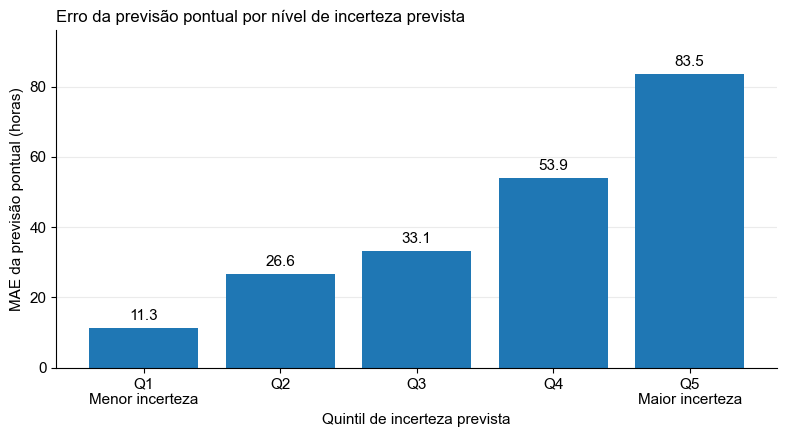

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Dados
# ---------------------------------------------------------

grupos = [
    "Q1\nMenor incerteza",
    "Q2",
    "Q3",
    "Q4",
    "Q5\nMaior incerteza"
]

mae = [11.3, 26.6, 33.1, 53.9, 83.5]

casos_acima_7d = [0.6, 3.2, 5.7, 13.2, 23.1]

spread_p95_p50 = [29.7, 91.5, 136.9, 223.8, 326.1]

x = np.arange(len(grupos))


# ---------------------------------------------------------
# Configuração visual
# ---------------------------------------------------------

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 11


# =========================================================
# FIGURA 1
# Erro absoluto por nível de incerteza prevista
# =========================================================

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(x, mae)

ax.set_xticks(x)
ax.set_xticklabels(grupos)

ax.set_ylabel("MAE da previsão pontual (horas)")
ax.set_xlabel("Quintil de incerteza prevista")

ax.set_title(
    "Erro da previsão pontual por nível de incerteza prevista",
    loc="left",
    fontsize=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

# Valores sobre as barras
for bar, valor in zip(bars, mae):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{valor:.1f}",
        ha="center",
        va="bottom"
    )

ax.set_ylim(0, max(mae) * 1.15)

plt.tight_layout()

plt.show()

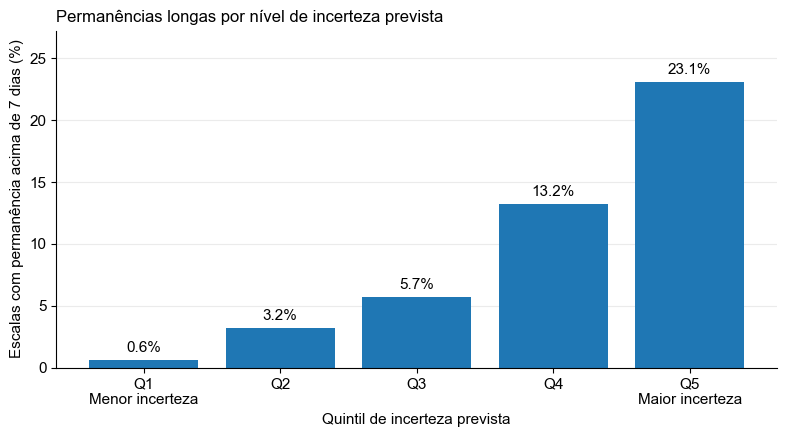

In [ ]:
# =========================================================
# FIGURA 2
# Casos acima de sete dias por nível de incerteza
# =========================================================

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(x, casos_acima_7d)

ax.set_xticks(x)
ax.set_xticklabels(grupos)

ax.set_ylabel("Escalas com permanência acima de 7 dias (%)")
ax.set_xlabel("Quintil de incerteza prevista")

ax.set_title(
    "Permanências longas por nível de incerteza prevista",
    loc="left",
    fontsize=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

# Valores sobre as barras
for bar, valor in zip(bars, casos_acima_7d):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{valor:.1f}%",
        ha="center",
        va="bottom"
    )

ax.set_ylim(0, max(casos_acima_7d) * 1.18)

plt.tight_layout()
plt.show()

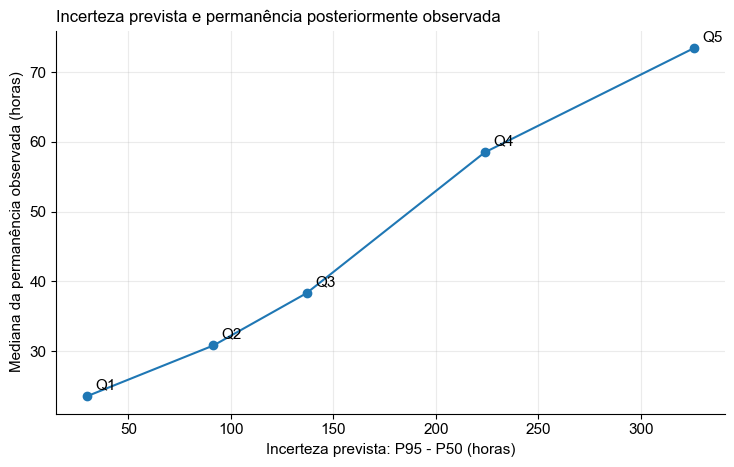

In [ ]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Dados
# ---------------------------------------------------------

spread_p95_p50 = [29.7, 91.5, 136.9, 223.8, 326.1]
permanencia_mediana = [23.5, 30.8, 38.3, 58.5, 73.5]

labels = ["Q1", "Q2", "Q3", "Q4", "Q5"]


# ---------------------------------------------------------
# Figura
# ---------------------------------------------------------

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 11

fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(
    spread_p95_p50,
    permanencia_mediana,
    marker="o"
)

for x, y, label in zip(
    spread_p95_p50,
    permanencia_mediana,
    labels
):
    ax.annotate(
        label,
        (x, y),
        xytext=(6, 5),
        textcoords="offset points"
    )

ax.set_xlabel("Incerteza prevista: P95 - P50 (horas)")
ax.set_ylabel("Mediana da permanência observada (horas)")

ax.set_title(
    "Incerteza prevista e permanência posteriormente observada",
    loc="left",
    fontsize=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()

plt.show()